In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.special import erf
import csv
import sys
sys.path.append('/storage/home/hcoda1/4/ashelby8/Manitoba/pyNab/src/')
import nabPy as Nab
sys.path.append('/storage/home/hcoda1/4/ashelby8/calibration/calibration/')
from FitClass import SnCalibration
from FitClass import CdCalibration
from config import conf
import FitFuncs
import pandas as pd
import pylab as py
np.set_printoptions(threshold=sys.maxsize)
pd.set_option("display.max_colwidth", 15)

In [2]:
runs = [1389,1374,1391,1392,1393,1395,1399]
runs_Cd = [1749,1751,1756,1763,1769,1772]

# bias = [-320,-300,-250,-180,-120,-90]
# runs = [1374]
# 1389,1374,1391,1392,1393,1395
# runs_Cd = [1751]
# 1749,1751,1756,1763,1769,1772
bias = [-320,-300,-250,-180,-120,-90,-60]

In [5]:
data = []
for i in range(len(runs)):
    with open('/storage/home/hcoda1/4/ashelby8/output%d.csv'%runs[i]) as f:
        csv.DictReader(f)
        data.append(pd.read_csv(f))
dataAll = pd.concat(data,ignore_index = True)

In [4]:
data = []
for i in range(len(runs_Cd)):
    with open('/storage/home/hcoda1/4/ashelby8/output%d.csv'%runs_Cd[i]) as f:
        csv.DictReader(f)
        data.append(pd.read_csv(f))
dataAll_Cd = pd.concat(data,ignore_index = True)

In [18]:
dataAll[dataAll['run']==1389][dataAll['pixel']==114]

,run,pixel,Bias Voltage,Proton,trap rise,trap length,trap decay,Proton Energy,Cd109,Sn113,...,ecap,chi2_e,xray,chi2_x,CE,Xray,CE hist,Xray hist,CE errors,Xray errors
14,1389,114,-320,False,1250,50,1250,0,False,True,...,[ 2.4220161...,0.189609,[ 1.6402057...,535.351782,2,3,[0 0 0 1 1 ...,[3101 2131 ...,[[ 4.511843...,[[ 2.292078...


In [6]:
names = []
for i in range(10):
    names.append('p%d'%i)
names_xray = []
for i in range(15):
    names_xray.append('p%d'%i)

In [7]:
#create the parameter data frames
df_ecap_Sn = {}
df_ecap_err_Sn = {}
for k in range(len(runs)):
    print(runs[k])
    df1 = {}
    df1_err = {}
    for i in range(len(names)):
        df1[names[i]] = {}
        df1_err[names[i]] = {}
        for j in range(20):
            j = j+k*21
            par_list = np.float64(dataAll[dataAll['run']==runs[k]]['ecap'][j].replace('[','').replace(']','').split()).tolist()
            arr = []
            arr+= [np.float64(dataAll[dataAll['run']==runs[k]]['CE errors'][j].replace('\n','').replace('[[','').replace(']]','').split('] [')[i].split()).tolist() for i in range(len(par_list))]
            err_list = np.sqrt(np.diag(np.array(arr))).tolist()
            if len(par_list) != len(names):
                par_list.extend(['']*(len(names)-len(par_list)))
                err_list.extend(['']*(len(names)-len(err_list)))
            df1[names[i]][j] = par_list[i]
            df1_err[names[i]][j] = err_list[i]
    ecap_data_Sn = pd.DataFrame(df1)
    ecap_error_Sn = pd.DataFrame(df1_err)
    df_ecap_Sn[k] = df1
    df_ecap_err_Sn[k] = df1_err
    
df_xray_Sn = {}
df_xray_err_Sn = {}
for k in range(len(runs)):
    df2 = {}
    df2_err = {}
    for i in range(len(names_xray)):
        df2[names_xray[i]] = {}
        df2_err[names_xray[i]] = {}
        for j in range(20):
            j = j+k*21
            par_list = np.float64(dataAll[dataAll['run']==runs[k]]['xray'][j].replace('[','').replace(']','').split()).tolist()
            arr = []
            arr+= [np.float64(dataAll[dataAll['run']==runs[k]]['Xray errors'][j].replace('\n','').replace('[[','').replace(']]','').split('] [')[i].split()).tolist() for i in range(len(par_list))]
            err_list = np.sqrt(np.diag(np.array(arr))).tolist()
            
            if len(par_list) != len(names_xray):
                par_list.extend(['']*(len(names_xray)-len(par_list)))
                err_list.extend(['']*(len(names_xray)-len(err_list)))
            df2[names_xray[i]][j] = par_list[i]
            df2_err[names_xray[i]][j] = err_list[i]
    xray_data_Sn = pd.DataFrame(df2)
    xray_error_Sn = pd.DataFrame(df2_err)
    df_xray_Sn[k] = df2
    df_xray_err_Sn[k] = df2_err

1389
1374
1391
1392
1393
1395
1399


In [3]:
pd.DataFrame(df_ecap_Sn[5])

NameError: name 'df_ecap_Sn' is not defined

In [9]:
#create the parameter data frames
df_ecap_Cd = {}
df_ecap_err_Cd = {}
for k in range(len(runs_Cd)):
    print(runs_Cd[k])
    df1 = {}
    df1_err = {}
    for i in range(len(names)):
        df1[names[i]] = {}
        df1_err[names[i]] = {}
        for j in range(20):
            j = j+k*21
            par_list = np.float64(dataAll_Cd[dataAll_Cd['run']==runs_Cd[k]]['ecap'][j].replace('[','').replace(']','').split()).tolist()
            arr = []
            arr+= [np.float64(dataAll_Cd[dataAll_Cd['run']==runs_Cd[k]]['CE errors'][j].replace('\n','').replace('[[','').replace(']]','').split('] [')[i].split()).tolist() for i in range(len(par_list))]
            err_list = np.sqrt(np.diag(np.array(arr))).tolist()
            if len(par_list) != len(names):
                par_list.extend(['']*(len(names)-len(par_list)))
                err_list.extend(['']*(len(names)-len(err_list)))
            df1[names[i]][j] = par_list[i]
            df1_err[names[i]][j] = err_list[i]
    ecap_data_Cd = pd.DataFrame(df1)
    ecap_error_Cd = pd.DataFrame(df1_err)
    df_ecap_Cd[k] = df1
    df_ecap_err_Cd[k] = df1_err
    
df_xray_Cd = {}
df_xray_err_Cd = {}
for k in range(len(runs_Cd)):
#     print(runs_Cd[k])
    df2 = {}
    df2_err = {}
    for i in range(len(names_xray)):
        df2[names_xray[i]] = {}
        df2_err[names_xray[i]] = {}
        for j in range(20):
            j = j+k*21
            par_list = np.float64(dataAll_Cd[dataAll_Cd['run']==runs_Cd[k]]['xray'][j].replace('[','').replace(']','').split()).tolist()
            
            arr = []
#             if j==16:
#                 err_list = np.sqrt(np.diag(np.zeros((len(par_list),len(par_list))))).tolist()
#                 err_list.extend(['']*(len(names_xray)-len(err_list)))
#             else:
            arr+= [np.float64(dataAll_Cd[dataAll_Cd['run']==runs_Cd[k]]['Xray errors'][j].replace('\n','').replace('[[','').replace(']]','').split('] [')[i].split()).tolist() for i in range(len(par_list))]
            err_list = np.sqrt(np.diag(np.array(arr))).tolist()
            if len(par_list) != len(names_xray):
                par_list.extend(['']*(len(names_xray)-len(par_list)))
                err_list.extend(['']*(len(names_xray)-len(err_list)))
            df2[names_xray[i]][j] = par_list[i]
            df2_err[names_xray[i]][j] = err_list[i]
    xray_data_Cd = pd.DataFrame(df2)
    xray_error_Cd = pd.DataFrame(df2_err)
    df_xray_Cd[k] = df2
    df_xray_err_Cd[k] = df2_err

1749
1751
1756
1763
1769
1772


In [10]:
pd.DataFrame(df_xray_err_Cd[0])

,p0,p1,p2,p3,p4,p5,p6,p7,p8,p9,p10,p11,p12,p13,p14
0,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf,,,
1,2.375570e+02,0.652566,9.992515e+01,9.335444e-01,1.002420e+00,3.732820e+00,1.700987e-01,0.329201,6.910323e+08,691032336.4...,0.767267,0.010219,,,
2,1.073113e+02,0.141220,5.539780e+00,2.332329e-01,3.876237e-01,2.675551e+00,2.252768e-01,0.388840,3.066111e+15,30661111004...,0.392554,0.005508,,,
3,1.640006e+02,0.086407,4.874081e+00,1.000866e+00,1.751865e+00,4.902234e+00,2.792827e-01,0.570307,6.511022e+15,65110221624...,0.664514,0.009238,,,
4,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.0,0.0,0.0,,,
5,2.020939e+02,0.095481,1.804957e+00,1.338253e-01,2.388886e-01,3.931895e+15,3.931895e+15,0.229661,3.220727e-03,,,,,,
6,6.128011e+02,3.328268,3.217102e+02,3.953911e-01,3.562579e-01,2.850545e+00,1.904151e-01,0.377231,6.088584e+07,60885843.10...,0.565097,0.007625,,,
7,2.982982e+02,0.147731,1.225734e+18,1.696437e+15,1.024672e+16,3.607394e+00,2.567510e-01,0.403592,7.354752e+15,73547515457...,0.602298,0.006851,,,
8,3.465903e+08,46.930434,2.941422e+00,2.493179e-01,5.499896e-01,7.242904e+15,7.242904e+15,0.841029,1.151309e-02,,,,,,
9,inf,inf,inf,inf,inf,inf,inf,inf,inf,,,,,,


In [11]:
def cal_data(dataAll,run,ecap_data,xray_data,ecap_err,xray_err,index):
    calibration_data = []
    sig_data = []
    calibration_error = []
    sig_error = []
    for i in range(20):
        points = []
        sig = []
        pnts_err = []
        sig_err = []
        
        i = i+21*index
        if dataAll[dataAll['run']==run]['CE'][i]==3 or dataAll[dataAll['run']==run]['CE'][i]==2:
            points.append(ecap_data['p1'][i])
            points.append(ecap_data['p4'][i])
#             points.append(ecap_data['p4'][i]*CEpeak)
            pnts_err.append(ecap_err['p1'][i])
            pnts_err.append(ecap_err['p4'][i])
        
            sig.append(ecap_data['p2'][i])
            sig.append(ecap_data['p5'][i])
            sig_err.append(ecap_err['p2'][i])
            sig_err.append(ecap_err['p5'][i])

        if dataAll[dataAll['run']==run]['CE'][i]==1:
            points.append(ecap_data['p1'][i])
            sig.append(ecap_data['p2'][i])
            
            pnts_err.append(ecap_err['p1'][i])
            sig_err.append(ecap_err['p2'][i])
            
        if dataAll[dataAll['run']==run]['Xray'][i]==5:
            points.append(xray_data['p9'][i])
            sig.append(xray_data['p10'][i])

            pnts_err.append(xray_err['p9'][i])
            sig_err.append(xray_err['p10'][i])
        
        if dataAll[dataAll['run']==run]['Xray'][i]==4:
            points.append(xray_data['p6'][i])
            sig.append(xray_data['p7'][i])

            pnts_err.append(xray_err['p6'][i])
            sig_err.append(xray_err['p7'][i])
            
        if dataAll[dataAll['run']==run]['Xray'][i]==3:
            points.append(xray_data['p3'][i])
            sig.append(xray_data['p4'][i])
            
            pnts_err.append(xray_err['p3'][i])
            sig_err.append(xray_err['p4'][i])

        calibration_data.append(points)
        sig_data.append(sig)
        calibration_error.append(pnts_err)
        sig_error.append(sig_err)
        
    return calibration_data, sig_data, calibration_error, sig_error

In [12]:
def calibration_quad(x,a,b,c):
    return a*x**2 + b*x+c

def calibration_lin(x,a,b):
    return a*x + b

In [13]:
calibration_Sn = []
sigma_Sn = []
calibration_error_Sn = []
sigma_error_Sn = []
for i in range(len(runs)):
    pars, sig, pars_err, sig_err = cal_data(dataAll,runs[i],pd.DataFrame(df_ecap_Sn[i]),pd.DataFrame(df_xray_Sn[i]),pd.DataFrame(df_ecap_err_Sn[i]),pd.DataFrame(df_xray_err_Sn[i]),i)
    calibration_Sn.append(pars)
    sigma_Sn.append(sig)
    calibration_error_Sn.append(pars_err)
    sigma_error_Sn.append(sig_err)

In [14]:
calibration_Cd = []
sigma_Cd = []
calibration_error_Cd = []
sigma_error_Cd = []
for i in range(len(runs_Cd)):
    pars, sig, pars_err, sig_err = cal_data(dataAll_Cd,runs_Cd[i],pd.DataFrame(df_ecap_Cd[i]),pd.DataFrame(df_xray_Cd[i]),pd.DataFrame(df_ecap_err_Cd[i]),pd.DataFrame(df_xray_err_Cd[i]),i)
    calibration_Cd.append(pars)
    sigma_Cd.append(sig)
    calibration_error_Cd.append(pars_err)
    sigma_error_Cd.append(sig_err)

In [100]:
np.argsort(calibration_Sn[0][0]),np.argsort(np.argsort(calibration_Sn[0][0])),calibration_error_Sn[0][0],calibration_error_Sn[0][0][2],calibration_error_Sn[0][0][0],calibration_error_Sn[0][0][1],calibration_Sn[0][0],np.sort(calibration_Sn[0][0])






(array([2, 0, 1]),
 array([1, 2, 0]),
 [np.float64(0.1464310069623234),
  0.9801619493736736,
  np.float64(0.30414927486351173)],
 np.float64(0.30414927486351173),
 np.float64(0.1464310069623234),
 0.9801619493736736,
 [np.float64(596.919784), 637.604589, np.float64(39.2571075)],
 array([ 39.2571075, 596.919784 , 637.604589 ]))

In [101]:
ADC_data_Sn = []
ADC_error_Sn = []
ADC_sigma_Sn = []
ADC_sigma_error_Sn = []
for j in range(len(calibration_Sn)):
    ADC_data_Sn.append([np.sort(calibration_Sn[j][i]) for i in range(len(calibration_Sn[j]))])
    idx = [[np.argsort(calibration_Sn[j][i])] for i in range(len(calibration_Sn[j]))]
    cal_err = []
    sig = []
    sig_err = []
    for i in range(len(idx)):
        cal_err.append([calibration_error_Sn[j][i][idx[i][0][k]] for k in range(len(idx[i][0]))])
        sig.append([sigma_Sn[j][i][idx[i][0][k]] for k in range(len(idx[i][0]))])
        sig_err.append([sigma_error_Sn[j][i][idx[i][0][k]] for k in range(len(idx[i][0]))])
    ADC_error_Sn.append(cal_err)
    ADC_sigma_Sn.append(sig)
    ADC_sigma_error_Sn.append(sig_err)
    

ADC_data_Cd = []
ADC_error_Cd = []
ADC_sigma_Cd = []
ADC_sigma_error_Cd = []
for j in range(len(calibration_Cd)):
    ADC_data_Cd.append([np.sort(calibration_Cd[j][i]) for i in range(len(calibration_Cd[j]))])
    idx = [[np.argsort(calibration_Cd[j][i])] for i in range(len(calibration_Cd[j]))]
    cal_err = []
    sig = []
    sig_err = []
    for i in range(len(idx)):
        cal_err.append([calibration_error_Cd[j][i][idx[i][0][k]] for k in range(len(idx[i][0]))])
        sig.append([sigma_Cd[j][i][idx[i][0][k]] for k in range(len(idx[i][0]))])
        sig_err.append([sigma_error_Cd[j][i][idx[i][0][k]] for k in range(len(idx[i][0]))])
    ADC_error_Cd.append(cal_err)
    ADC_sigma_Cd.append(sig)
    ADC_sigma_error_Cd.append(sig_err)

In [102]:
ADC_error_Sn

[[[np.float64(0.30414927486351173),
   np.float64(0.1464310069623234),
   0.9801619493736736],
  [0.5959358698719184, np.float64(0.1497923866556642), 0.17616175322697036],
  [np.float64(0.37320183279292723),
   np.float64(0.19494768323834988),
   1.0999062096378946],
  [np.float64(0.5651025694508918),
   np.float64(0.16032246006096587),
   0.7567099682176784],
  [0.5316872924943759, np.float64(0.16438862004408944), 0.5993279911701105],
  [np.float64(0.24827226325145546),
   np.float64(0.21622468452977334),
   0.3831730744715761],
  [np.float64(0.2924992345289129),
   np.float64(0.18200753336057277),
   0.4912625530202765],
  [np.float64(0.4073929331738586),
   np.float64(0.21471868805485936),
   0.6220132715625929],
  [np.float64(0.4885183149074352),
   np.float64(0.3215987499975707),
   0.9309021575869292],
  [np.float64(0.36330737674867), 0.1775058153976934],
  [np.float64(0.5744568782772124),
   np.float64(0.3355246026746772),
   0.5369655687285732],
  [np.float64(0.3730796804973436

In [103]:
eV_points_total = [22.102983701979042,24.13701754385965,62.5196,84.2278,363.758,387.461]
eV_points_Sn = [24.13701754385965,363.758,387.461]
eV_points_Cd = [22.102983701979042,62.5196,84.2278]

In [104]:
pix = [0,3,6,11,14]
# pix = [0]

In [105]:
# ADC_data_Sn[j][i][1] = ADC_data_Sn[j][i][1]+2*1.6
# ADC_data_Sn[j][i][2] = ADC_data_Sn[j][i][2]+2*1.6

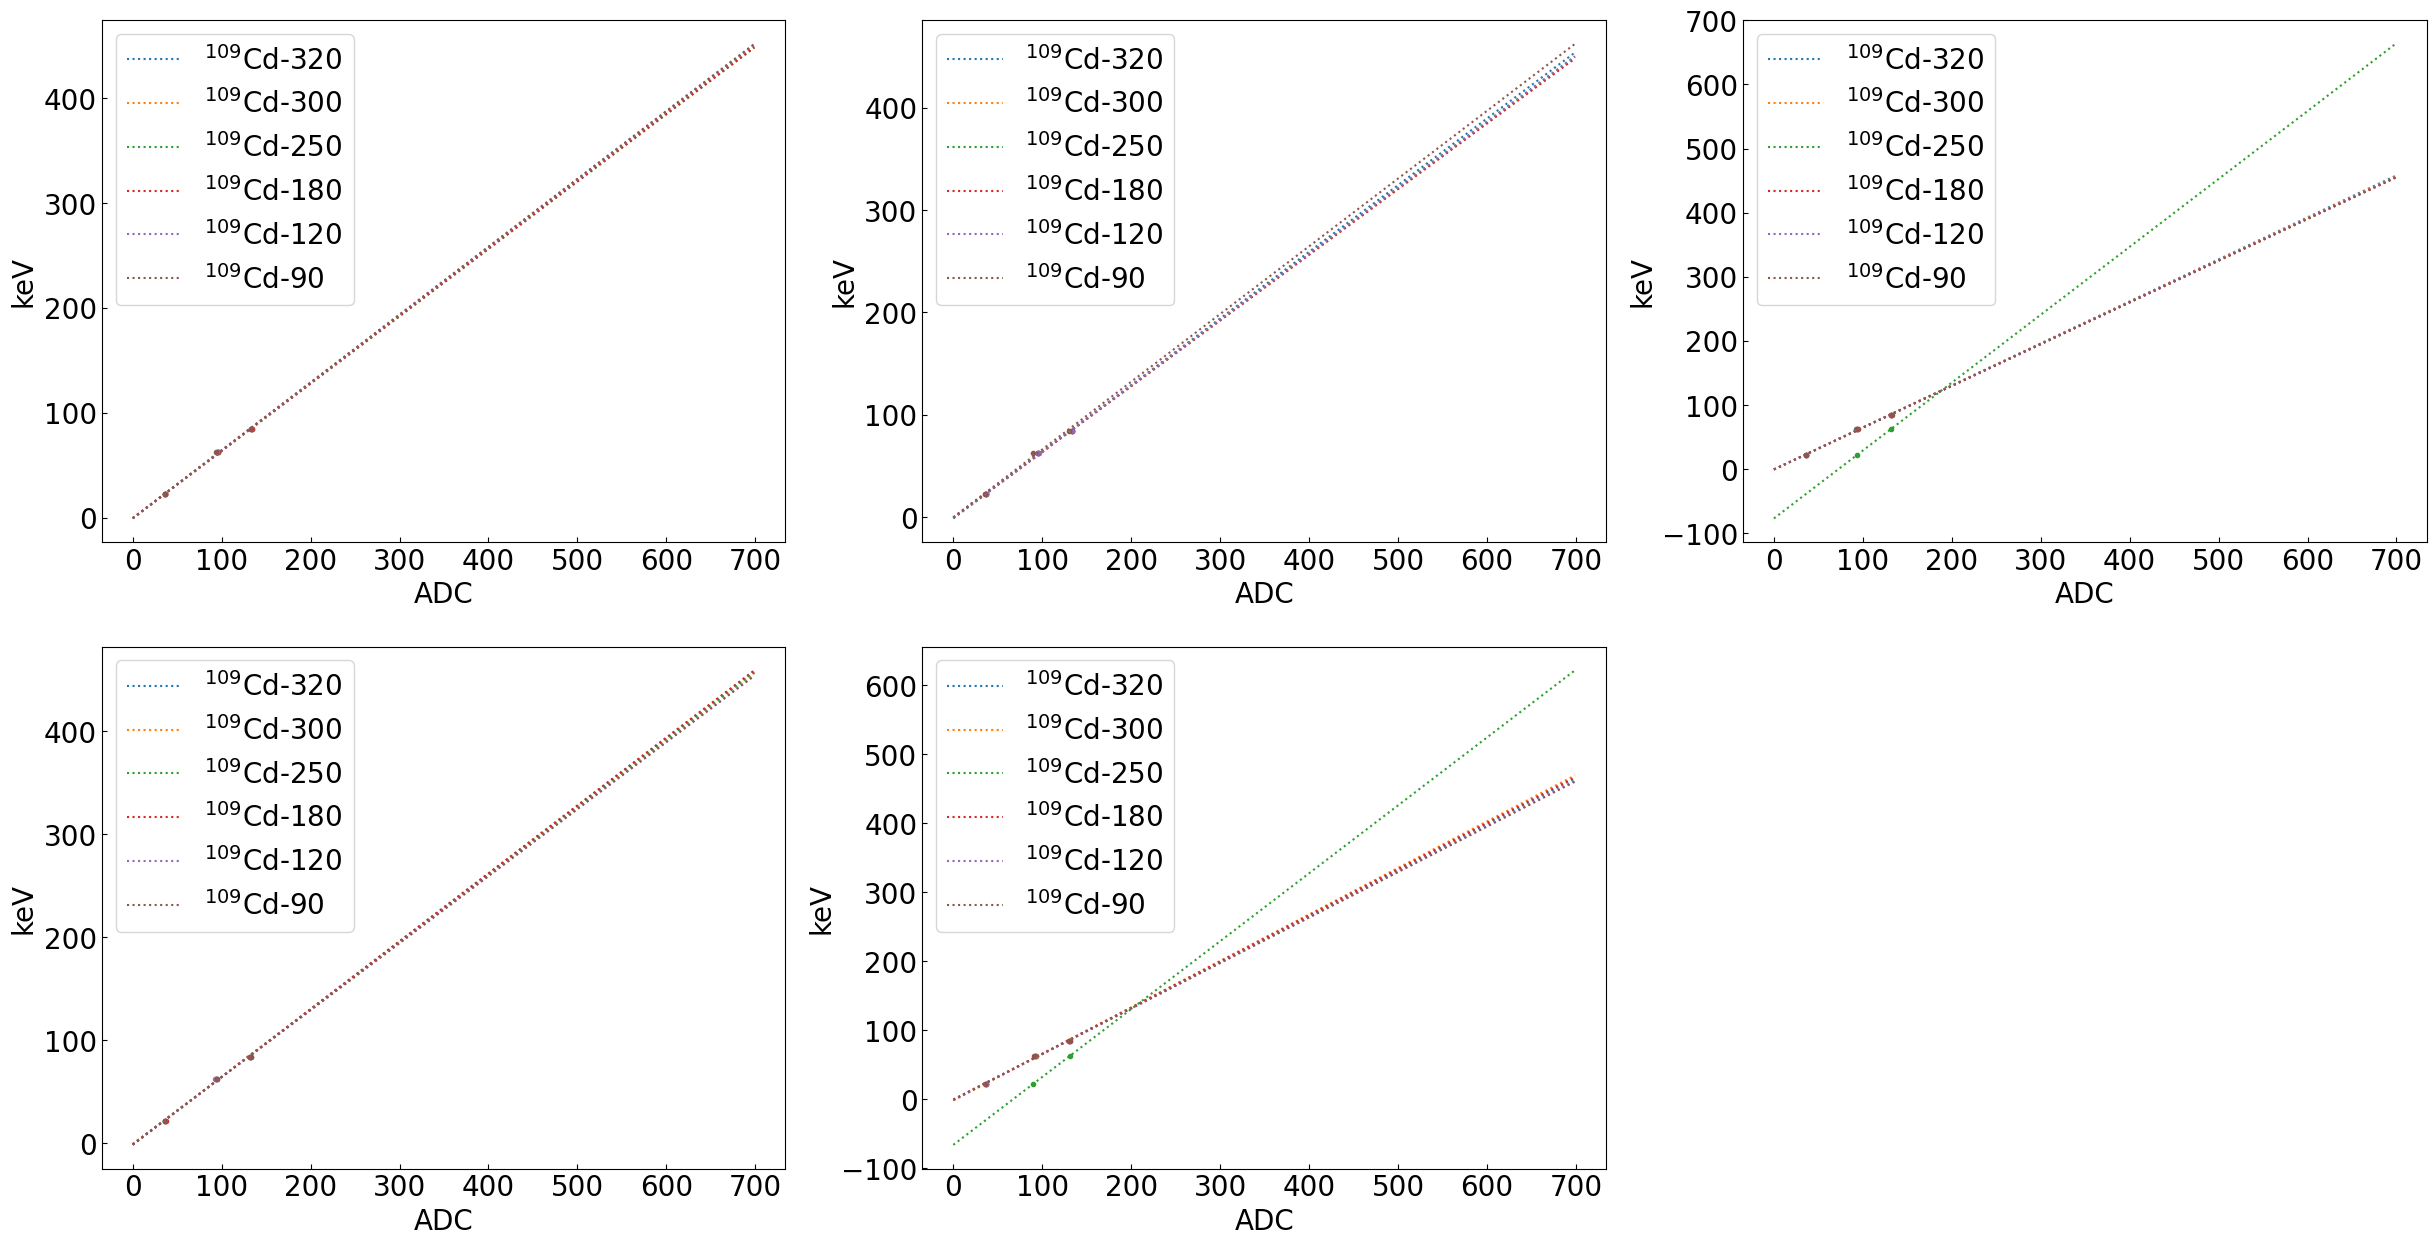

In [21]:
nrows,ncols=10,3
py.figure(figsize=(10*ncols,8*nrows))
x = np.arange(0,700)


tokeV_Cd = []
cnt = 0
for i in pix:
    Cd = []
    cnt +=1
    ax=py.subplot(nrows,ncols,cnt)
    ax.tick_params(direction='in',which='both',axis='both',labelsize=20)
    for j in range(len(runs_Cd)):
        if len(ADC_data_Sn[j][i])<=1:
            Sn.append([0])
            pass
    
        if len(ADC_data_Cd[j][i])<4:
            ax.set_ylabel('keV',size=20)
            ax.set_xlabel('ADC',size=20)
            a, b = np.polyfit(ADC_data_Cd[j][i][0:len(ADC_data_Cd[j][i])],eV_points_Cd[0:len(ADC_data_Cd[j][i])],deg=1)
            
            ax.scatter(ADC_data_Cd[j][i][0:len(ADC_data_Cd[j][i])],eV_points_Cd[0:len(ADC_data_Cd[j][i])],marker = '.')
            
            Cd.append([a,b])
            
            ax.plot(x,calibration_lin(x,a,b),linestyle = ':',label = r'$^{109}$Cd%d'%bias[j])

        ax.legend(loc="upper left",prop={'size':20})
    tokeV_Cd.append(Cd)

plt.show()

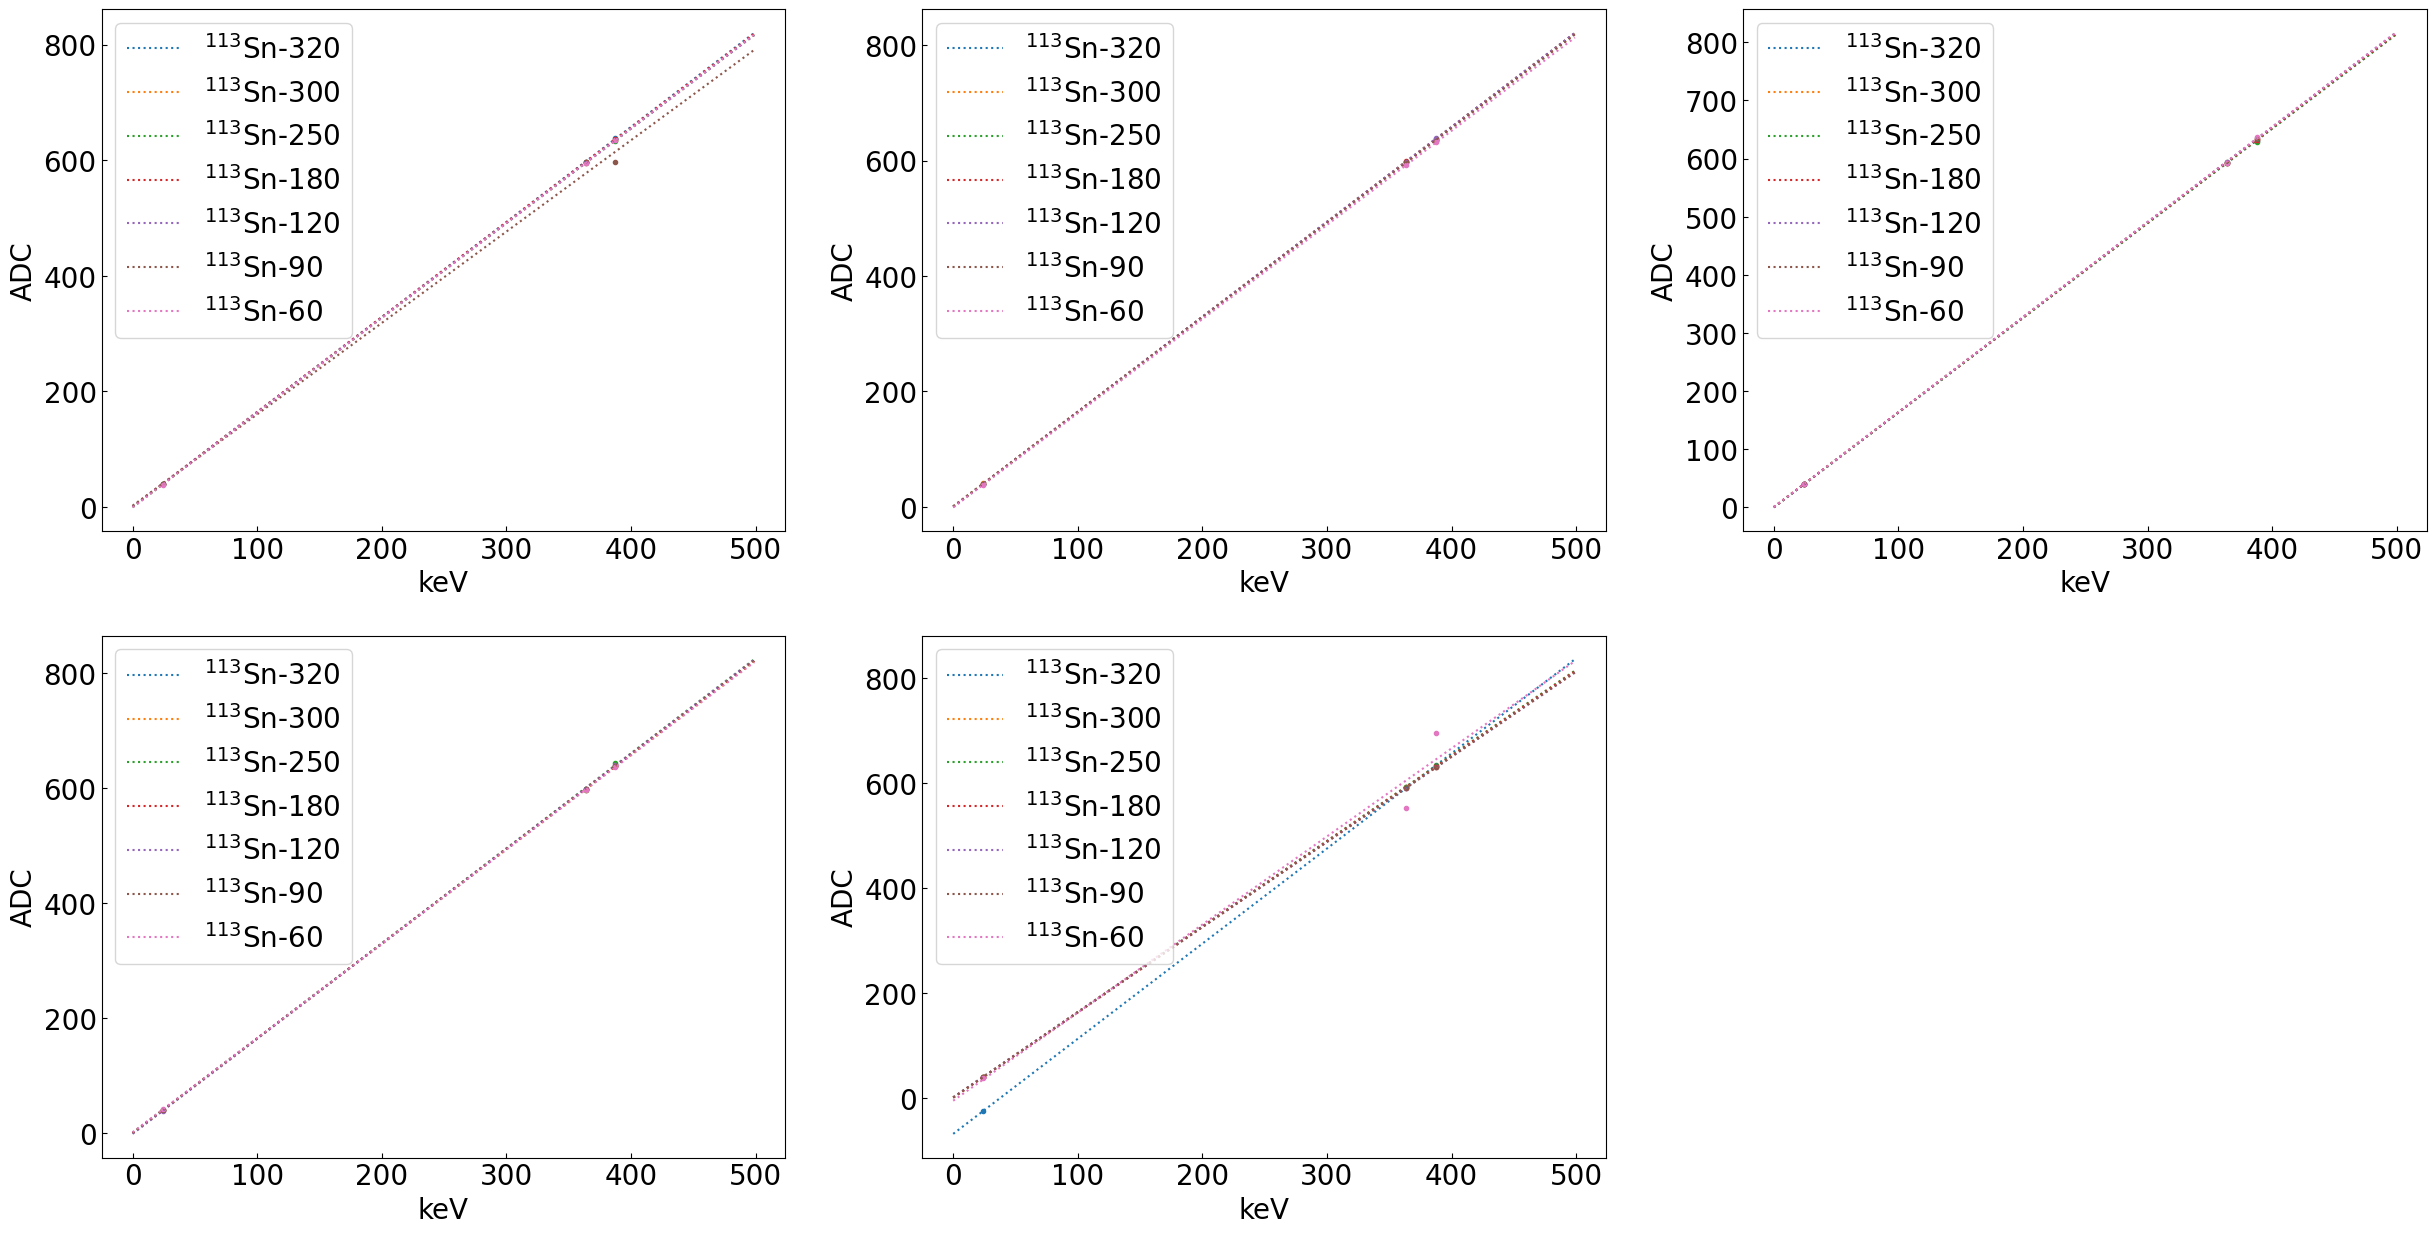

In [106]:
nrows,ncols=10,3
py.figure(figsize=(10*ncols,8*nrows))
x = np.arange(0,500)

toADC_Sn = []
cnt = 0
for i in pix:
    Sn = []
    cnt +=1
    ax=py.subplot(nrows,ncols,cnt)
    ax.tick_params(direction='in',which='both',axis='both',labelsize=20)
    for j in range(len(runs)):
        if len(ADC_data_Sn[j][i])<=1:
            Sn.append([0])
            pass
        if len(ADC_data_Sn[j][i])<4:
            ax.set_ylabel('ADC',size=20)
            ax.set_xlabel('keV',size=20)
            
            a, b = np.polyfit(eV_points_Sn[0:len(ADC_data_Sn[j][i])],ADC_data_Sn[j][i][0:len(ADC_data_Sn[j][i])],deg=1)
            ax.scatter(eV_points_Sn[0:len(ADC_data_Sn[j][i])],ADC_data_Sn[j][i][0:len(ADC_data_Sn[j][i])],marker = '.')
            
            Sn.append([a,b])
            ax.plot(x,calibration_lin(x,a,b),linestyle = ':',label = r'$^{113}$Sn%d'%bias[j])
            ax.legend(loc="upper left",prop={'size':20})
    toADC_Sn.append(Sn)

plt.show()

In [22]:
# nrows,ncols=10,3
# py.figure(figsize=(10*ncols,8*nrows))
# x = np.arange(0,500)

# toADC_Sn = []
# toADC_Cd = []
# cnt = 0
# for i in pix:
#     Sn = []
#     Cd = []
#     for j in range(len(runs)):
#         cnt +=1
#         ax=py.subplot(nrows,ncols,cnt)
#         ax.tick_params(direction='in',which='both',axis='both',labelsize=20)
#         if len(ADC_data_Sn[j][i])<=1:
#             Sn.append([0])
#             pass
#         if len(ADC_data_Sn[j][i])<4:
#             ax.set_ylabel('ADC',size=20)
#             ax.set_xlabel('keV',size=20)
            
#             a, b = np.polyfit(eV_points_Sn[0:len(ADC_data_Sn[j][i])],ADC_data_Sn[j][i][0:len(ADC_data_Sn[j][i])],deg=1)
#             ax.scatter(eV_points_Sn[0:len(ADC_data_Sn[j][i])],ADC_data_Sn[j][i][0:len(ADC_data_Sn[j][i])],marker = '.')
            
#             Sn.append([a,b])
#             ax.plot(x,calibration_lin(x,a,b),linestyle = ':',label = r'$^{113}$Sn')
            
#     toADC_Sn.append(Sn)
#     toADC_Cd.append(Cd)

# plt.show()

In [107]:
toADC_Sn

[[[np.float64(1.644768892251667), np.float64(-0.4999925254261172)],
  [np.float64(1.638937753507838), np.float64(-0.41459385403923305)],
  [np.float64(1.636645982136787), np.float64(-0.011587112912803324)],
  [np.float64(1.6396026956523093), np.float64(0.6290382816161314)],
  [np.float64(1.6345602926489753), np.float64(0.5443723521215592)],
  [np.float64(1.5804286860719965), np.float64(2.2019564850472864)],
  [np.float64(1.6393202808721723), np.float64(-0.8759720853097157)]],
 [[np.float64(1.640926616234921), np.float64(0.421736684789963)],
  [np.float64(1.6403752053240914), np.float64(0.7689018740737183)],
  [np.float64(1.6447595329103895), np.float64(0.255133515100459)],
  [np.float64(1.6449916816538925), np.float64(0.0349907400203339)],
  [np.float64(1.645401126048672), np.float64(0.20642884823967453)],
  [np.float64(1.6400772163160764), np.float64(-0.09949226908417834)],
  [np.float64(1.6317138177401436), np.float64(-1.2459392314284736)]],
 [[np.float64(1.6302892370293864), np.floa

In [22]:
pix = [0]

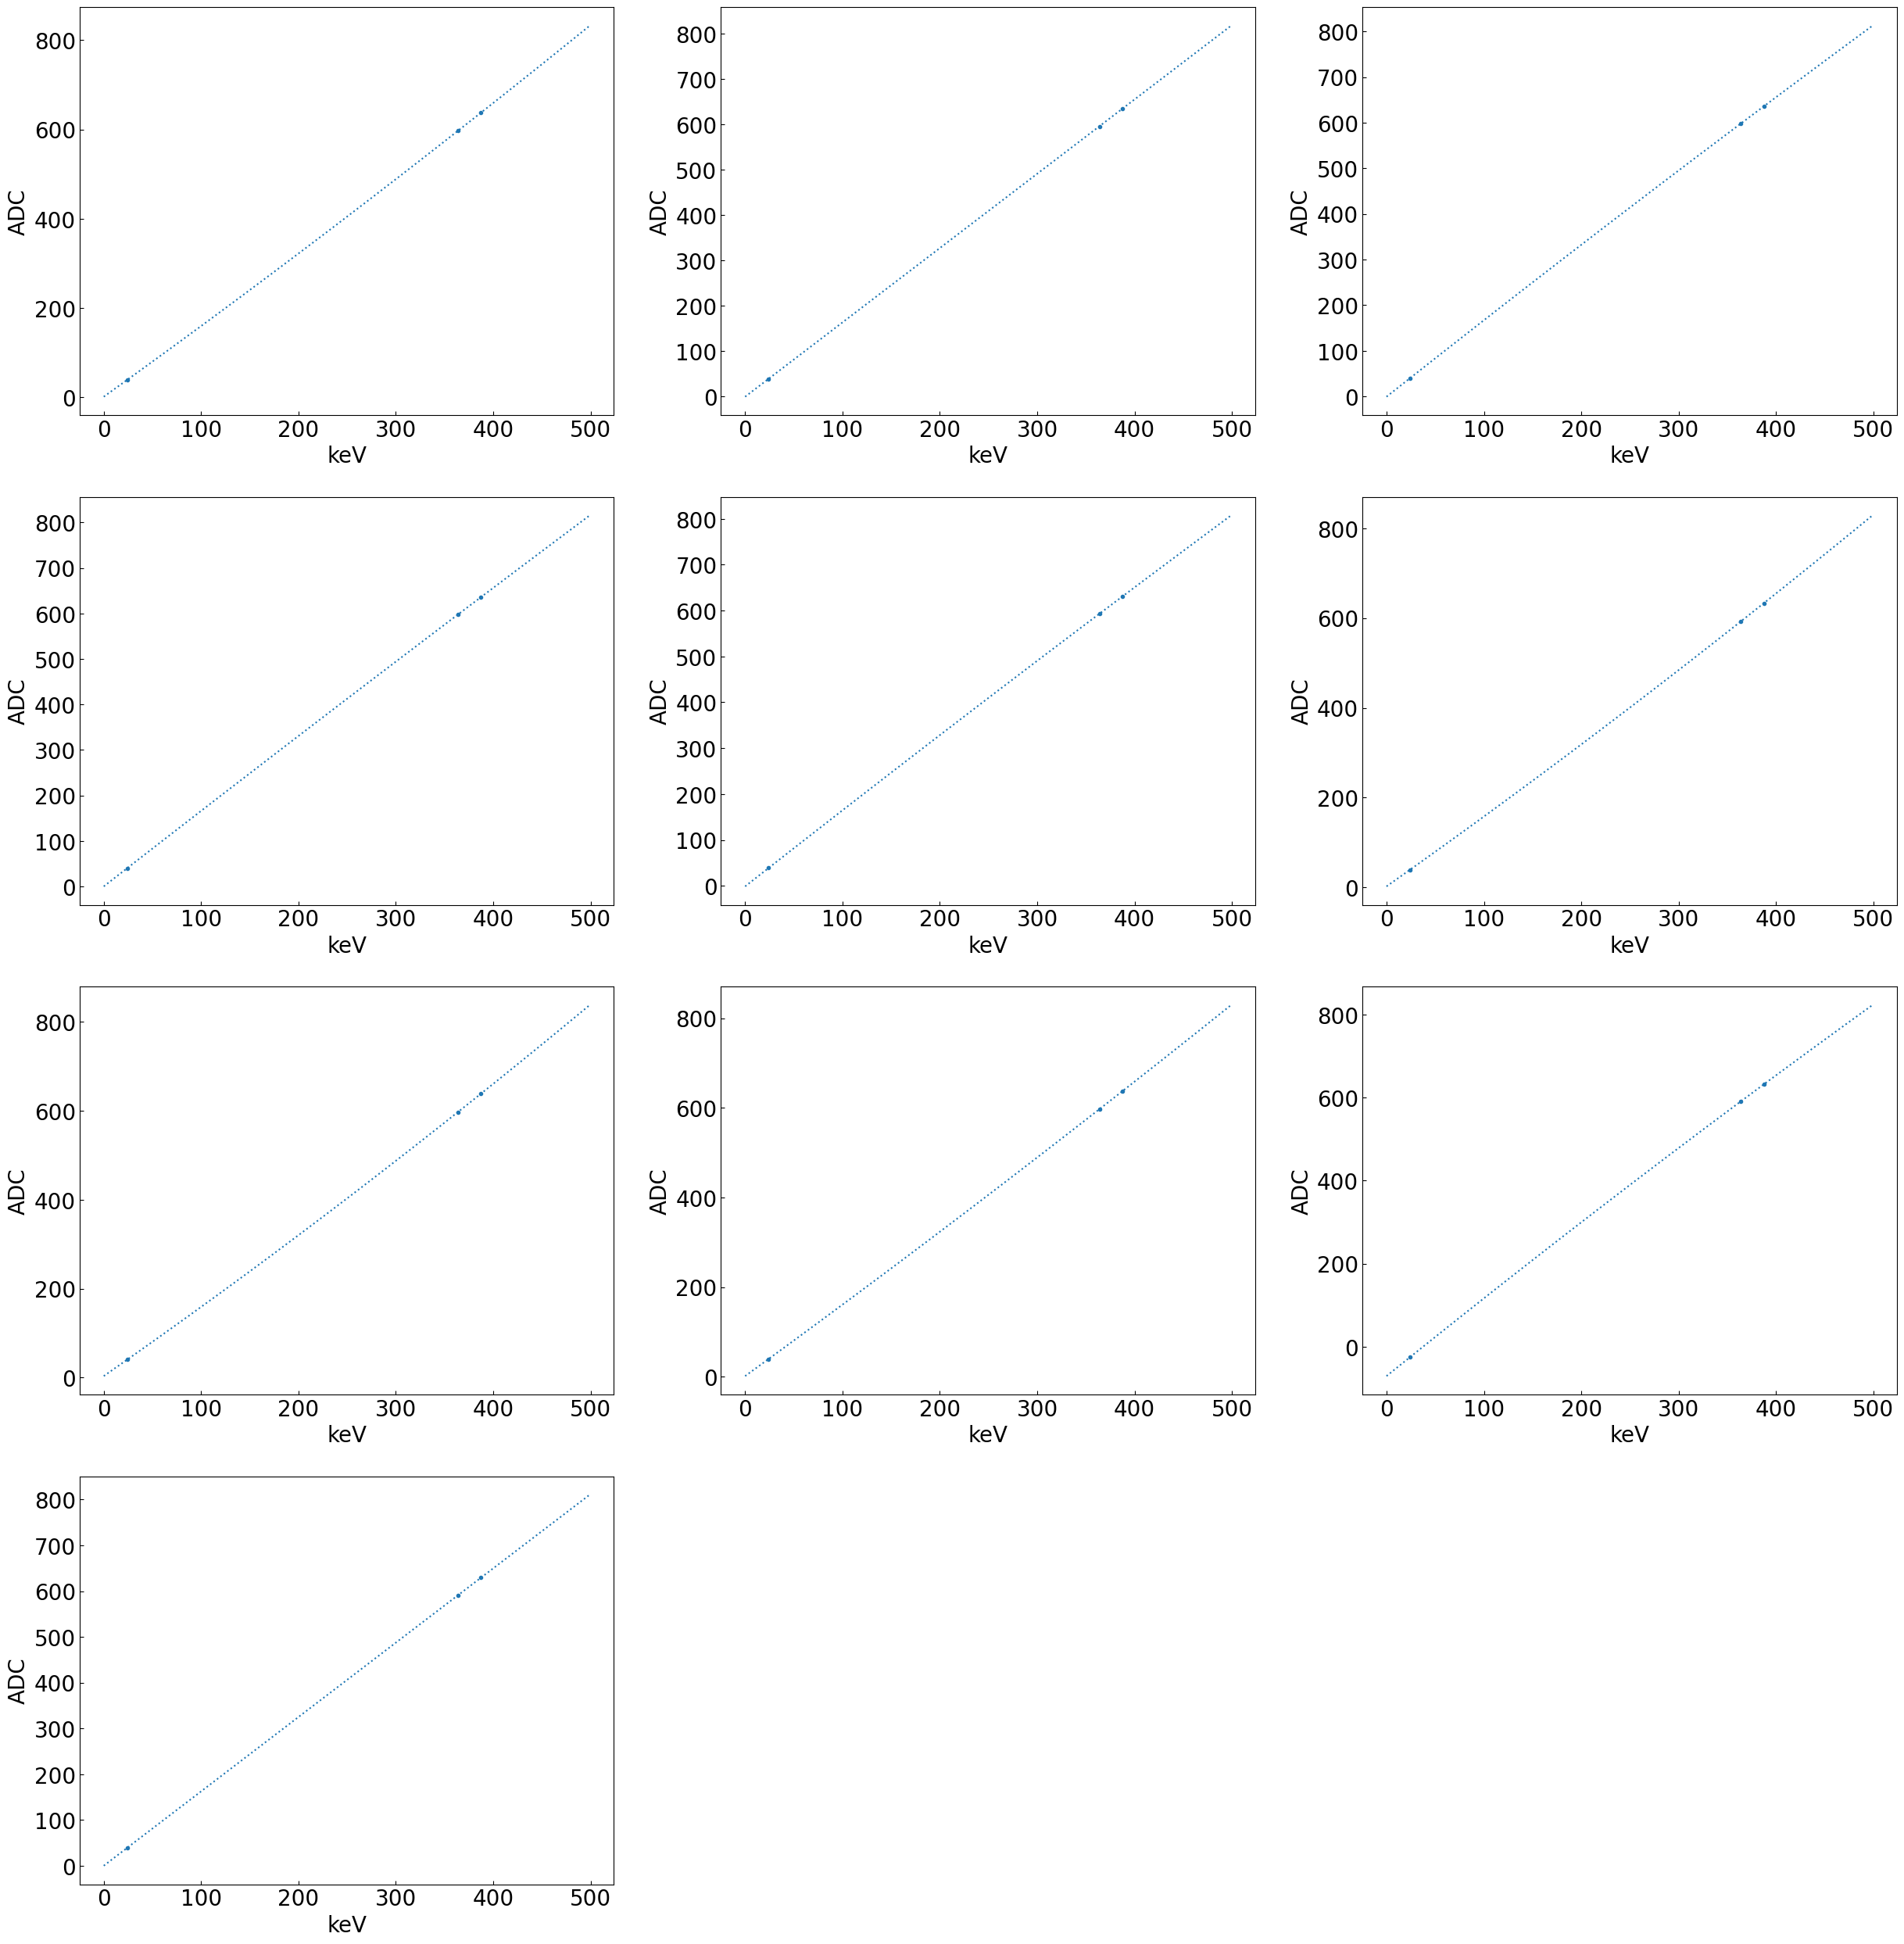

In [74]:
nrows,ncols=10,3
py.figure(figsize=(10*ncols,8*nrows))
x = np.arange(0,500)

toADC_Sn_quad = []
toADC_Sn_quad_err = []
cnt = 0
for i in pix:
    Sn = []
    Snerr = []
    for j in range(len(runs)-5):
        cnt +=1
        ax=py.subplot(nrows,ncols,cnt)
        ax.tick_params(direction='in',which='both',axis='both',labelsize=20)
        if len(ADC_data_Sn[j][i])<=1:
            Sn.append([0])
            pass
        if len(ADC_data_Sn[j][i])<4:
            ax.set_ylabel('ADC',size=20)
            ax.set_xlabel('keV',size=20)
            
            pars, err = curve_fit(calibration_quad,eV_points_Sn[0:len(ADC_data_Sn[j][i])],ADC_data_Sn[j][i][0:len(ADC_data_Sn[j][i])],sigma = ADC_error_Sn[j][i][0:len(ADC_data_Sn[j][i])],absolute_sigma = True)
            ax.scatter(eV_points_Sn[0:len(ADC_data_Sn[j][i])],ADC_data_Sn[j][i][0:len(ADC_data_Sn[j][i])],marker = '.')
            
            Sn.append(pars)
            Snerr.append(err)
            ax.plot(x,calibration_quad(x,pars[0],pars[1],pars[2]),linestyle = ':',label = r'$^{113}$Sn')
    
    toADC_Sn_quad.append(Sn)
    toADC_Sn_quad_err.append(Snerr)
plt.show()

In [78]:
np.sqrt(np.diag(toADC_Sn_quad_err[0][1]))[0]

array([5.16788474e-05, 2.02317144e-02, 6.76020672e-01])

In [129]:
toADC_Sn_quad[0][1]

array([ 1.06043958e-06,  1.63851216e+00, -4.04642490e-01])

In [132]:
toADC_Sn_quad[0][1][0]*600/(toADC_Sn_quad[0][1][1]+ (toADC_Sn_quad[0][1][2]/600))

np.float64(0.00038847788632584543)

In [108]:
def convert(x,pars):
    y = []
    for i in pars:
        lin = i[0]
        intercept = i[1]
        y.append(lin*x + intercept)     
    return y

In [24]:
dx = (300-90)
dy = (3.67-3.81)
dT = 150.824458-122.4513491
dkeV = np.abs((dy/dx)*dT)

In [37]:
dkeV

np.float64(0.018915405933333344)

In [26]:
# dADC = convert(dkeV,toADC_Cd[0])

NameError: name 'toADC_Cd' is not defined

In [ ]:
dADC

In [33]:
corrected_ADC_data_Cd = ADC_data_Cd[0][0] - dADC

In [43]:
(convert(eV_points_Cd[0],toADC_Sn[0])-corrected_ADC_data_Cd[0])/((convert(eV_points_Cd[0],toADC_Sn[0])+corrected_ADC_data_Cd[0])/2)



array([0.01771407])

In [40]:
corrected_ADC_data_Cd[0],ADC_data_Cd[0][0][0]

(np.float64(35.18203437497802), np.float64(36.4627032))

In [37]:
convert(eV_points_Cd[0],toADC_Sn[0]),convert(eV_points_Cd[1],toADC_Sn[0]),convert(eV_points_Cd[2],toADC_Sn[0])

([np.float64(35.810820600302655)],
 [np.float64(102.05113892016938)],
 [np.float64(137.62952746086825)])

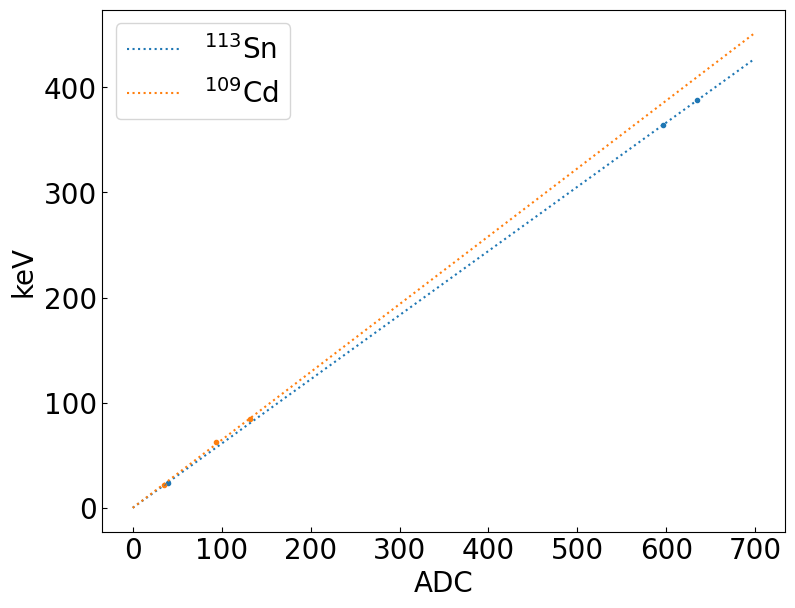

In [38]:
nrows,ncols=10,3
py.figure(figsize=(10*ncols,8*nrows))
x = np.arange(0,700)

tokeV_Sn = []
tokeV_Cd_corrected = []
cnt = 0
for i in pix:
    Sn = []
    Cd = []
    for j in range(len(runs)):
        cnt +=1
        ax=py.subplot(nrows,ncols,cnt)
        ax.tick_params(direction='in',which='both',axis='both',labelsize=20)
        if len(ADC_data_Sn[j][i])<=1:
            Sn.append([0])
            pass
        if len(ADC_data_Sn[j][i])<4:
            ax.set_ylabel('keV',size=20)
            ax.set_xlabel('ADC',size=20)
            
            a, b = np.polyfit(ADC_data_Sn[j][i][0:len(ADC_data_Sn[j][i])],eV_points_Sn[0:len(ADC_data_Sn[j][i])],deg=1)
            ax.scatter(ADC_data_Sn[j][i][0:len(ADC_data_Sn[j][i])],eV_points_Sn[0:len(ADC_data_Sn[j][i])],marker = '.')
            
            Sn.append([a,b])
            ax.plot(x,calibration_lin(x,a,b),linestyle = ':',label = r'$^{113}$Sn')
    
        if len(corrected_ADC_data_Cd)<4:
            ax.set_ylabel('keV',size=20)
            ax.set_xlabel('ADC',size=20)
            
            a, b = np.polyfit(corrected_ADC_data_Cd[0:len(corrected_ADC_data_Cd)],eV_points_Cd[0:len(corrected_ADC_data_Cd)],deg=1)
            
            ax.scatter(corrected_ADC_data_Cd[0:len(corrected_ADC_data_Cd)],eV_points_Cd[0:len(corrected_ADC_data_Cd)],marker = '.')
            
            Cd.append([a,b])
            
            ax.plot(x,calibration_lin(x,a,b),linestyle = ':',label = r'$^{109}$Cd')

        ax.legend(loc="upper left",prop={'size':20})
    tokeV_Sn.append(Sn)
    tokeV_Cd_corrected.append(Cd)

plt.show()

In [39]:
tokeV_Cd_corrected

[[[np.float64(0.6451579887225978), np.float64(0.18448749827033958)]]]

In [24]:
dfSn = {}
for i in range(len(toADC_Sn)):
    dfSn[i] = {}
    for j in range(len(toADC_Sn[i])):
        dfSn[i][j] = {'linear':toADC_Sn[i][j][0],'constant':toADC_Sn[i][j][1]}

In [56]:
dfCd = {}
for i in range(len(toADC_Cd)):
    dfCd[i] = {}
    for j in range(len(toADC_Cd[i])):
        dfCd[i][j] = {'linear':toADC_Cd[i][j][0],'constant':toADC_Cd[i][j][1]}

In [57]:
def horizontal(dfs):
    html = '<div style="display:flex">'
    for df in dfs:
        html += '<div style="margin-right: 32px">'
        html += df.to_html()
        html += '</div>'
    html += '</div>'
    display(HTML(html))
    
CSS = """
.output {
    flex-direction: row;
}
"""
from IPython.display import display, HTML
HTML('<style>{}</style>'.format(CSS))

In [58]:
horizontal([pd.DataFrame(dfSn[0]).T.set_index([pd.Index(['-320V', '-300V', '-250V', '-180V','-120V','-90V'])]).style.set_caption('76'),
            pd.DataFrame(dfSn[1]).T.set_index([pd.Index(['-320V', '-300V', '-250V', '-180V','-120V','-90V'])]).style.set_caption('87'),
            pd.DataFrame(dfSn[2]).T.set_index([pd.Index(['-320V', '-300V', '-250V', '-180V','-120V','-90V'])]).style.set_caption('97'),
            pd.DataFrame(dfSn[3]).T.set_index([pd.Index(['-320V', '-300V', '-250V', '-180V','-120V','-90V'])]).style.set_caption('106'),
            pd.DataFrame(dfSn[4]).T.set_index([pd.Index(['-320V', '-300V', '-250V', '-180V','-120V','-90V'])]).style.set_caption('114')
           ])


,linear,constant
-320V,1.644581,-0.429303
-300V,1.639060,-0.460504
-250V,1.636573,0.015806
-180V,1.644260,-1.122102
-120V,1.635600,0.546134
-90V,1.643438,-0.682082
,linear,constant
-320V,1.642497,0.269197
-300V,1.640375,0.768931
-250V,1.646189,0.145380


In [59]:
horizontal([pd.DataFrame(dfCd[0]).T.set_index([pd.Index(['-320V', '-300V', '-250V', '-180V','-120V','-90V'])]).style.set_caption('76'),
            pd.DataFrame(dfCd[1]).T.set_index([pd.Index(['-320V', '-300V', '-250V', '-180V','-120V','-90V'])]).style.set_caption('87'),
            pd.DataFrame(dfCd[2]).T.set_index([pd.Index(['-320V', '-300V', '-250V', '-180V','-120V','-90V'])]).style.set_caption('97'),
            pd.DataFrame(dfCd[3]).T.set_index([pd.Index(['-320V', '-300V', '-250V', '-180V','-120V','-90V'])]).style.set_caption('106'),
            pd.DataFrame(dfCd[4]).T.set_index([pd.Index(['-320V', '-300V', '-250V', '-180V','-120V','-90V'])]).style.set_caption('114')
           ])

,linear,constant
-320V,1.546172,1.245661
-300V,1.545447,1.251438
-250V,1.551635,1.305442
-180V,1.554365,1.135013
-120V,1.544843,0.985548
-90V,1.541831,0.766304
,linear,constant
-320V,1.532969,2.139955
-300V,1.551147,1.201721
-250V,1.546707,1.320078


In [60]:
# A = []
# for j in range(len(pix)):
#     a = []
#     for i in range(len(runs)):
#         a.append((toADC_Sn[j][i][1]-toADC_Cd[j][i][1],toADC_Cd[j][i][0]/toADC_Sn[j][i][0]))
#     A.append(a)

# new_ADC_data_Cd = []
# for j in range(len(pix)):
#     new_Cd = []
#     for i in range(len(ADC_data_Cd)):
#         new_Cd.append(ADC_data_Cd[i][j]*A[j][i][1])
#     new_ADC_data_Cd.append(new_Cd)
    
# ADC_data = []
# for j in range(len(pix)):
#     ADC = []
#     for i in range(len(new_ADC_data_Cd[j])):
#         ADC.append(np.sort(new_ADC_data_Cd[j][i].tolist()+ADC_data_Sn[i][j].tolist()))
#     ADC_data.append(ADC)
    
# nrows,ncols=2,3
# py.figure(figsize=(10*ncols,8*nrows))
# x = np.arange(0,600)

# toADC = []
# cnt = 0
# for i in range(len(pix)):
#     cnt+=1
#     ax=py.subplot(nrows,ncols,cnt)
#     ax.tick_params(direction='in',which='both',axis='both',labelsize=20)
#     ax.set_ylabel('ADC',size=20)
#     ax.set_xlabel('keV',size=20)
#     ADC = []
#     for j in range(len(runs)):
#         if len(ADC_data[i][j])<=1:
#             ADC.append([0])
#             pass
#     #         only include the eV points associated with the corresponding ADC value
#         if len(ADC_data[i][j])<7:
#             a, b, c = np.polyfit(eV_points_total[0:len(ADC_data[i][j])], ADC_data[i][j][0:len(ADC_data[i][j])],deg=2)

#             ax.scatter(eV_points_total[0:len(ADC_data[i][j])],ADC_data[i][j][0:len(ADC_data[i][j])],marker = '.',label = '%dV'%bias[j])

#             ADC.append([a,b,c])

#             ax.plot(x,calibration_quad(x,a,b,c),linestyle = ':')

#         ax.legend(loc="upper left",prop={'size':20})
#     toADC.append(ADC)
# plt.show()

# [print(toADC[0][i][0]*600/toADC[0][i][1]) for i in range(len(toADC[0]))]
# [print(toADC[1][i][0]*600/toADC[1][i][1]) for i in range(len(toADC[1]))]

# df = {}
# for i in range(len(toADC)):
#     df[i] = {}
#     for j in range(len(toADC[i])):
#         df[i][j] = {'quadratic':toADC[i][j][0],'linear':toADC[i][j][1],'constant':toADC[i][j][2]}
        
# horizontal([pd.DataFrame(df[0]).T.set_index([pd.Index(['-320V', '-300V', '-250V', '-180V','-120V','-90V'])]).style.set_caption('76'), 
#             pd.DataFrame(df[1]).T.set_index([pd.Index(['-320V', '-300V', '-250V', '-180V','-120V','-90V'])]).style.set_caption('87')])

In [109]:
toADC_Sn[0][0]

[np.float64(1.644768892251667), np.float64(-0.4999925254261172)]

In [110]:
def wave_fit(wave, func, pretrig=3000,p0=None):
    xdata = np.arange(0,len(wave))
    prewave = wave[0:int(pretrig)]
    base = np.average(prewave)
    ydata = wave - base
    if p0 == None:
        popt, pcov = curve_fit(func, xdata, ydata,maxfev=4000)
    
    else:
        try:
            popt, pcov = curve_fit(func, xdata, ydata, p0)
        except Exception as e:
            plt.plot(wave)
            return 0,0
    
    return func(xdata, *popt)+ base, popt

In [111]:
def wave_func(x, a,b,c,d,e,f):
    return a + b*x + c*x**2.0 + d*np.exp(-(x-e)/1250.0) / (1.0 + np.exp(-(x-e)/f))

In [112]:
def risetime(wave,fit_mid,low=0.1, high=0.9,pretrigger=[3000,3400], cut=0,max_delay=0, max_length=50):
    try:
        shift = np.mean(wave[pretrigger[0]:pretrigger[1]])
        wave = wave - shift
        if max_delay == 0:
            maxval = np.max(wave)
        else:
            maxval = np.mean(wave[3500+max_delay:3500+max_delay+max_length])

        wave = wave[cut:]
        xs = np.arange(len(wave))*4

        upperCross = maxval * high
        lowerCross = maxval * low

        x = np.arange(0,7000)

        upCrossPoint = np.argwhere(wave[int(fit_mid):]>upperCross)[0][0]+int(fit_mid)
        lowCrossPoint = np.argwhere(wave[:int(fit_mid)]<lowerCross)[-1][0]+1
        upper = np.interp(upperCross, wave[upCrossPoint-1:upCrossPoint+1], xs[upCrossPoint-1:upCrossPoint+1])
        lower = np.interp(lowerCross, wave[lowCrossPoint-1:lowCrossPoint+1], xs[lowCrossPoint-1:lowCrossPoint+1])
        
        return upper-lower, [lower/4+cut, upper/4+cut, maxval+shift]
    except:
        plt.plot(wave)
        plt.show()
        return 0,[0,0,0]

In [113]:
def get_risetime(runNumber,pixel,lowerE,higherE):
    
    directory = '/storage/home/hcoda1/4/ashelby8/scratch/ManitobaData/'
    run = Nab.DataRun(directory, runNumber, ignoreEventFile = True)
    
    risetime_list = []
    time = []
    for i in range(len(pixel)):
        run.singleWaves().resetCuts()
        run.singleWaves().defineCut('pixel', '=', int(pixel[i]))
        print('got run')
        results = run.singleWaves().determineEnergyTiming(method='trap', params=[1250, 50, 1250])

        results.resetCuts()
        results.defineCut('energy', 'between',lowerE[i],higherE[i])

        cut = results.returnCut()
        run.singleWaves().defineCut('custom', cut)
        waves = run.singleWaves().waves()
        print('got waves')
        
        risetimeDistribution = []
        time_mid = []
        
        for i in range(len(waves)):
            func, par = wave_fit(waves[i].compute(),wave_func,p0=[-5,5e-7,1e-10,-20,3500,10])
            if type(par)==int:
                pass
            else:
                time_mid.append(par[4])
#                 print(risetime(waves[i].compute(),par[4],low=0.1, high=0.9))
                risetimeDistribution.append(risetime(waves[i].compute(),par[4],low=0.1, high=0.9)[0])

        risetime_list.append(risetimeDistribution)
        time.append(time_mid)
        
    return risetime_list, time

In [114]:
risetime

<function __main__.risetime(wave, fit_mid, low=0.1, high=0.9, pretrigger=[3000, 3400], cut=0, max_delay=0, max_length=50)>

In [115]:
low76 = convert(300,toADC_Sn[0])
high76 = convert(390,toADC_Sn[0])

low87 = convert(300,toADC_Sn[1])
high87 = convert(390,toADC_Sn[1])

low97 = convert(300,toADC_Sn[2])
high97 = convert(390,toADC_Sn[2])

low106 = convert(300,toADC_Sn[3])
high106 = convert(390,toADC_Sn[3])

low114 = convert(300,toADC_Sn[4])
high114 = convert(390,toADC_Sn[4])

In [116]:
pixel = [76,87,97,106,114]

low1389 = [low76[0],low87[0],low97[0],low106[0],low114[0]]
high1389 = [high76[0],high87[0],high97[0],high106[0],high114[0]]

low1374 = [low76[1],low87[1],low97[1],low106[1],low114[1]]
high1374 = [high76[1],high87[1],high97[1],high106[1],high114[1]]

low1391 = [low76[2],low87[2],low97[2],low106[2],low114[2]]
high1391 = [high76[2],high87[2],high97[2],high106[2],high114[2]]

low1392 = [low76[3],low87[3],low97[3],low106[3],low114[3]]
high1392 = [high76[3],high87[3],high97[3],high106[3],high114[3]]

low1393 = [low76[4],low87[4],low97[4],low106[4],low114[4]]
high1393 = [high76[4],high87[4],high97[4],high106[4],high114[4]]

low1395 = [low76[5],low87[5],low97[5],low106[5],low114[5]]
high1395 = [high76[5],high87[5],high97[5],high106[5],high114[5]]

low1399 = [low76[6],low87[6],low97[6],low106[6],low114[6]]
high1399 = [high76[6],high87[6],high97[6],high106[6],high114[6]]

got run
got waves
got run
got waves
got run
got waves
got run
got waves
got run
got waves


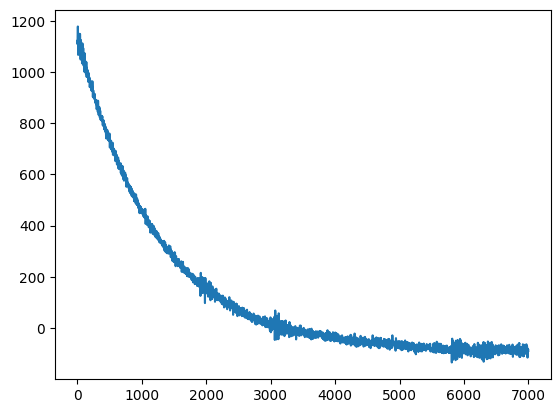

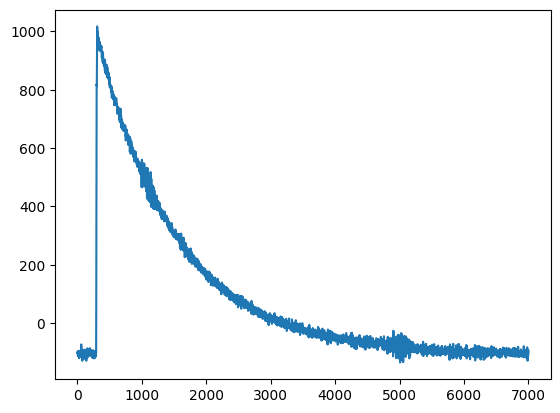

CPU times: user 51.6 s, sys: 6.63 s, total: 58.2 s
Wall time: 2min 23s


In [117]:
%%time 
risetime1389,time1389 = get_risetime(1389,pixel,low1389,high1389)

got run
got waves
got run
got waves


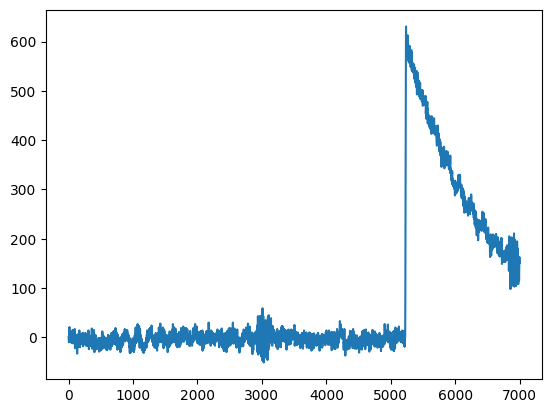

got run
got waves
got run
got waves
got run
got waves
CPU times: user 37.9 s, sys: 3.9 s, total: 41.8 s
Wall time: 1min 45s


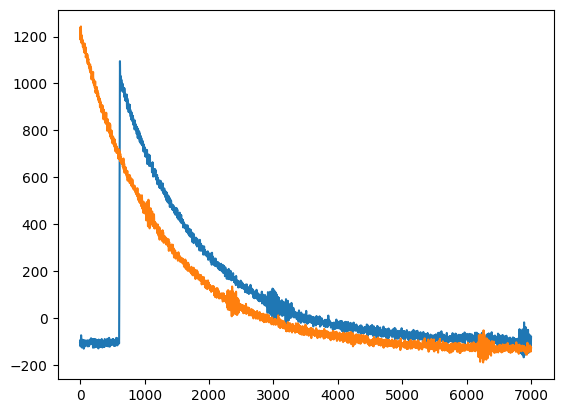

In [118]:
%%time 
risetime1391,time1391 = get_risetime(1391,pixel,low1391,high1391)

got run
got waves


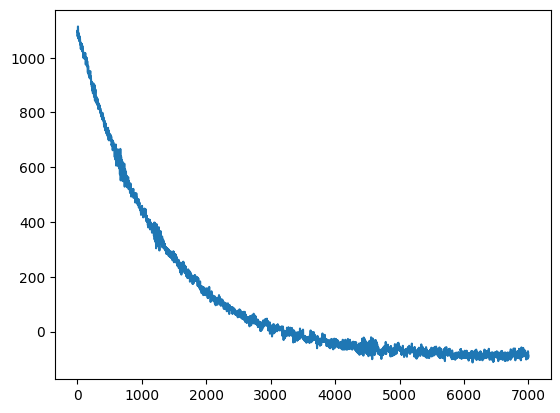

got run
got waves


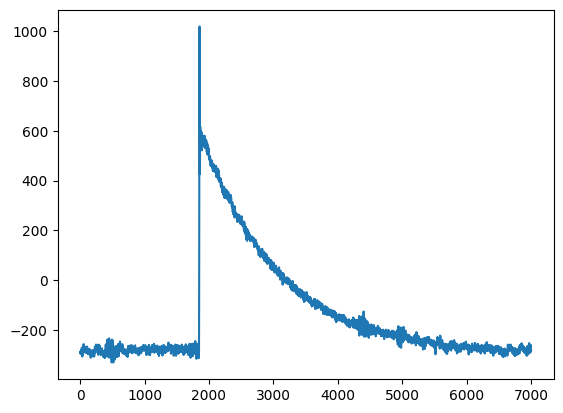

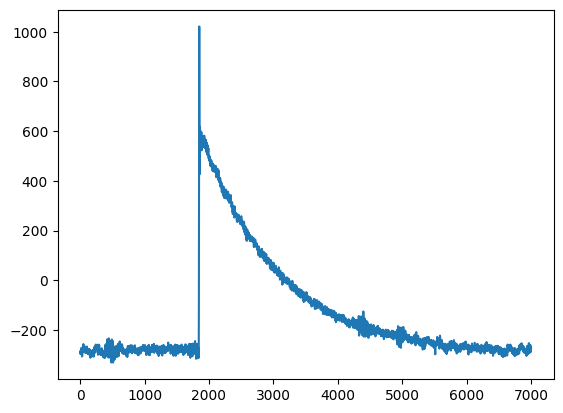

got run
got waves


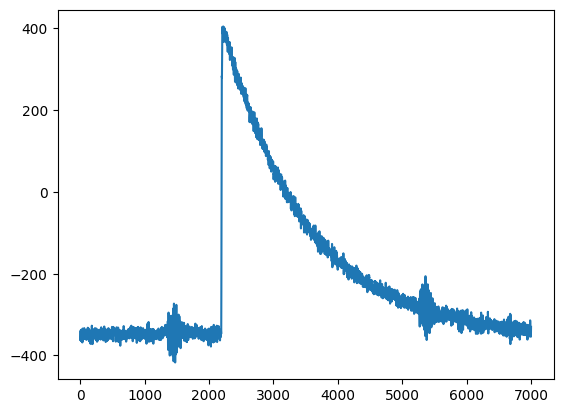

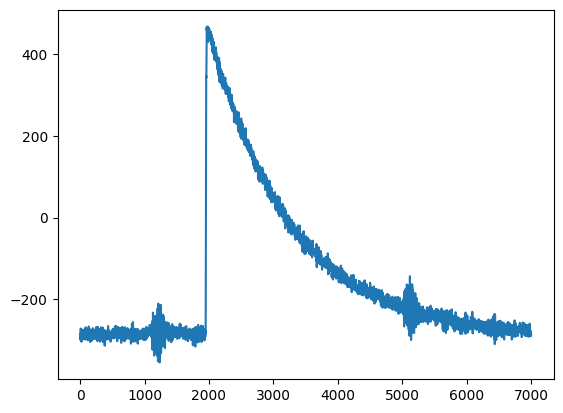

got run
got waves
got run
got waves
CPU times: user 1min 12s, sys: 6.94 s, total: 1min 19s
Wall time: 3min 27s


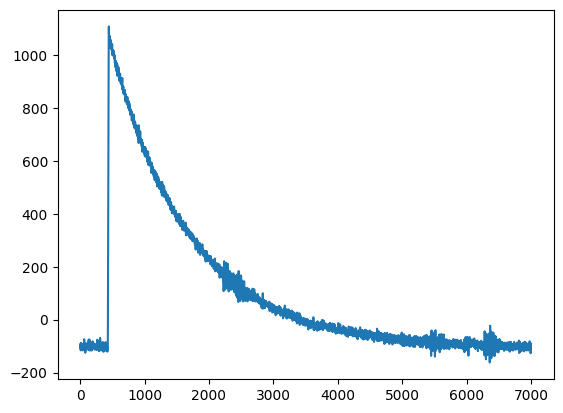

In [119]:
%%time 
risetime1392,time1392 = get_risetime(1392,pixel,low1392,high1392)

got run
got waves
got run
got waves
got run
got waves
got run
got waves


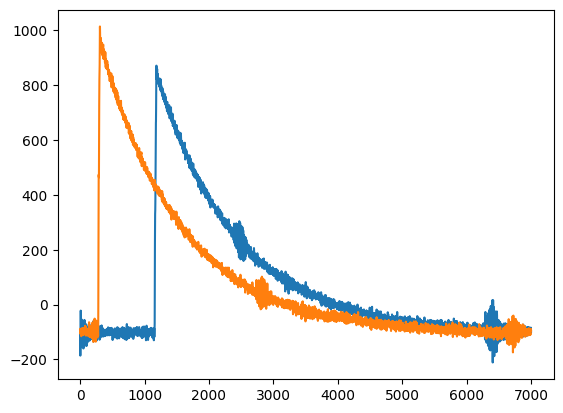

got run
got waves


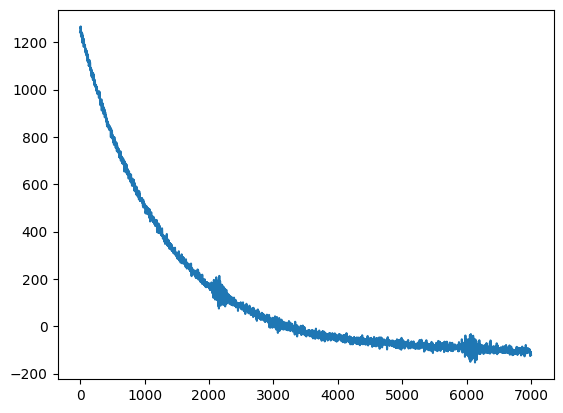

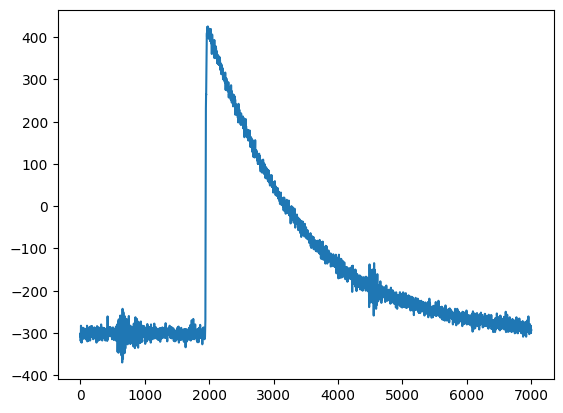

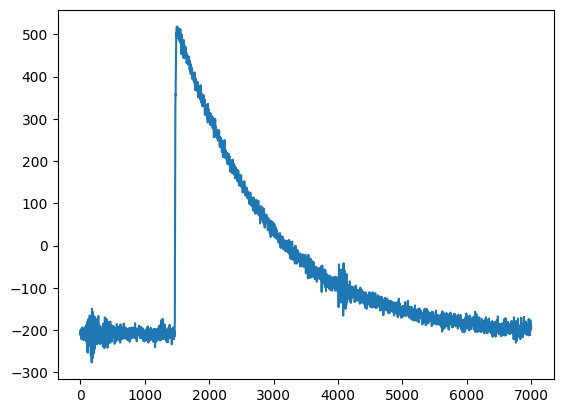

CPU times: user 40.4 s, sys: 3.98 s, total: 44.4 s
Wall time: 2min 7s


In [120]:
%%time 
risetime1393,time1393 = get_risetime(1393,pixel,low1393,high1393)

got run
got waves
got run
got waves
got run
got waves
got run
got waves


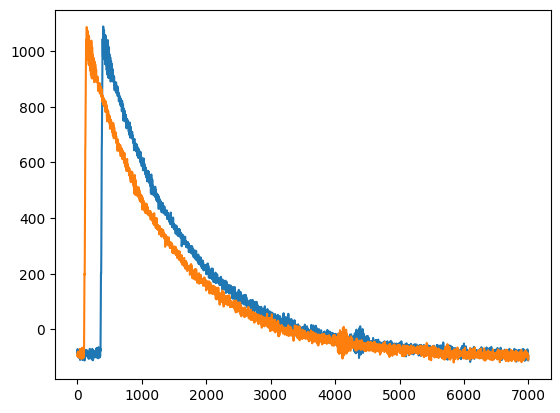

got run
got waves


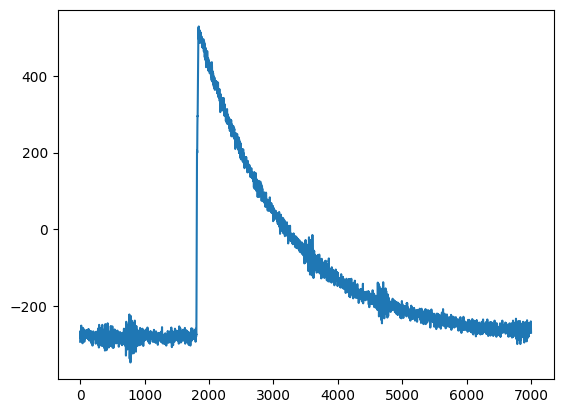

CPU times: user 39.9 s, sys: 4.02 s, total: 43.9 s
Wall time: 1min 58s


In [121]:
%%time 
risetime1395,time1395 = get_risetime(1395,pixel,low1395,high1395)

got run
got waves
got run
got waves
got run
got waves
got run
got waves


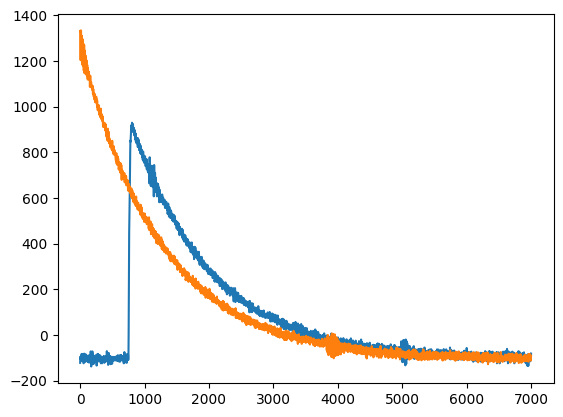

got run
got waves


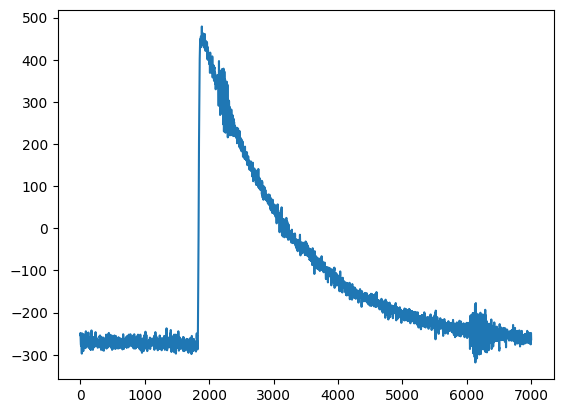

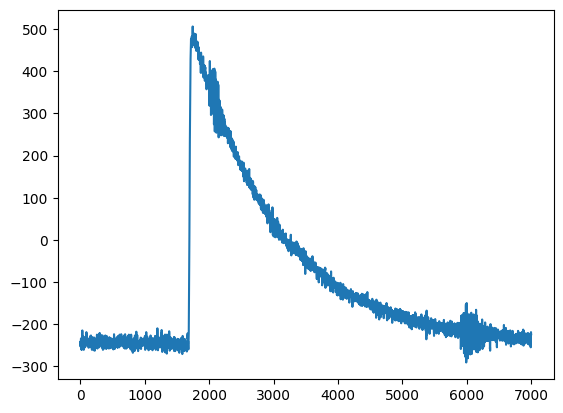

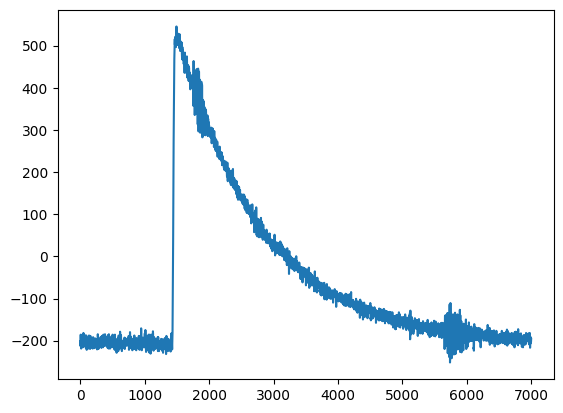

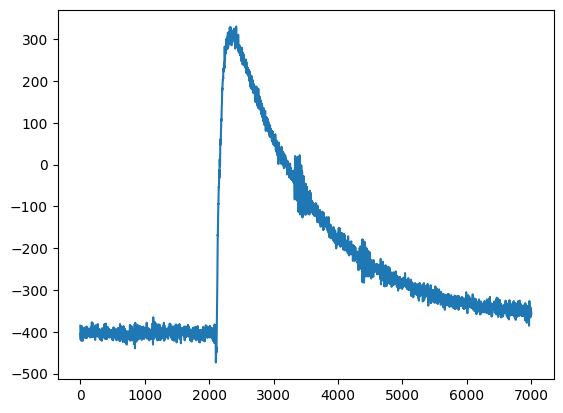

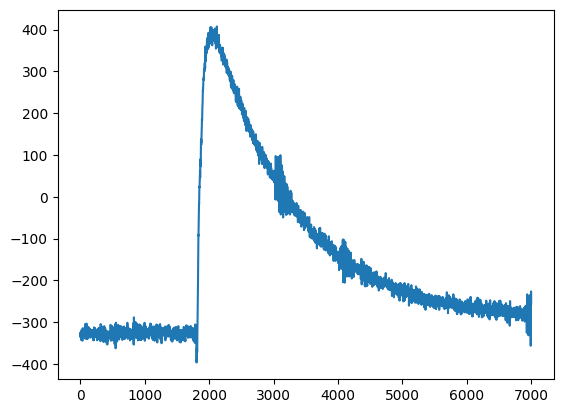

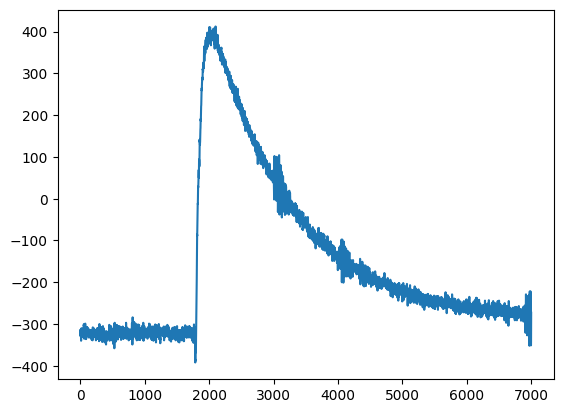

CPU times: user 51.4 s, sys: 5 s, total: 56.4 s
Wall time: 2min 50s


In [122]:
%%time 
risetime1399,time1399 = get_risetime(1399,pixel,low1399,high1399)

got run
got waves


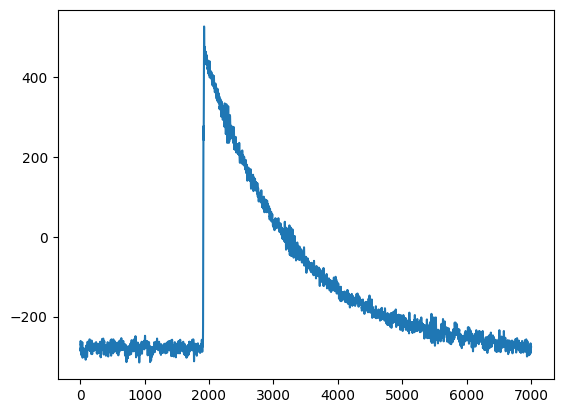

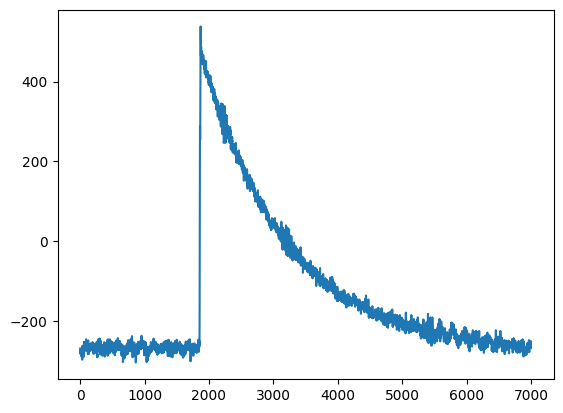

got run
got waves


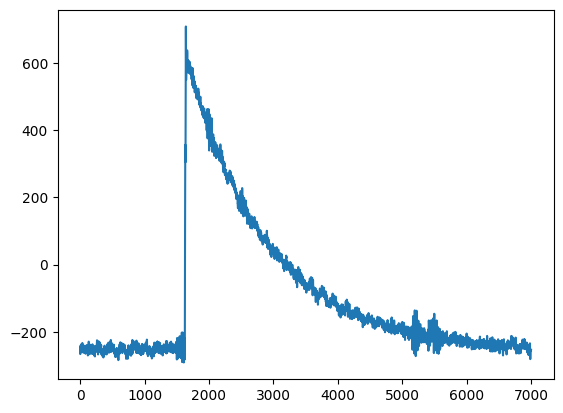

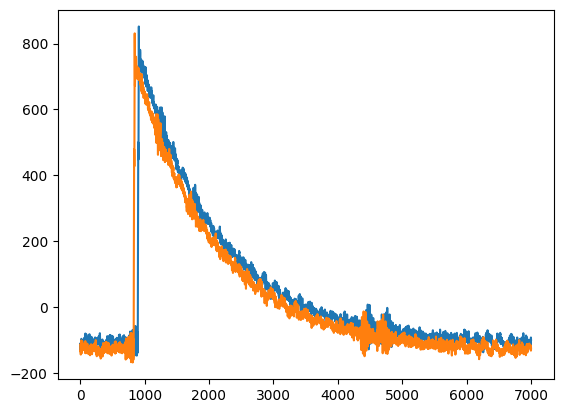

got run
got waves


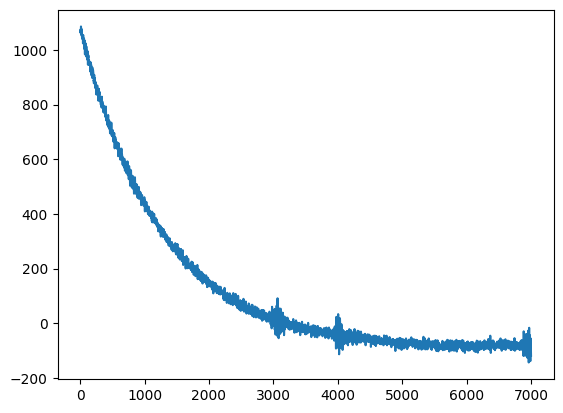

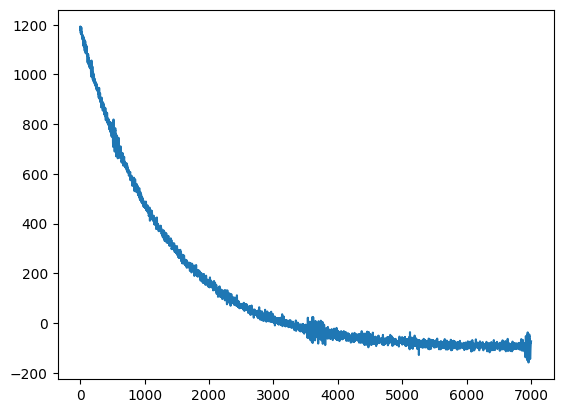

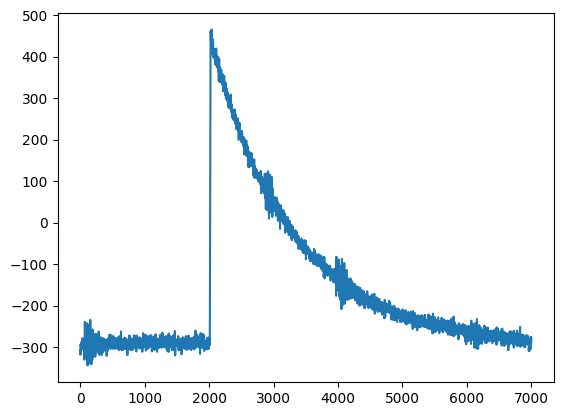

got run
got waves
got run
got waves


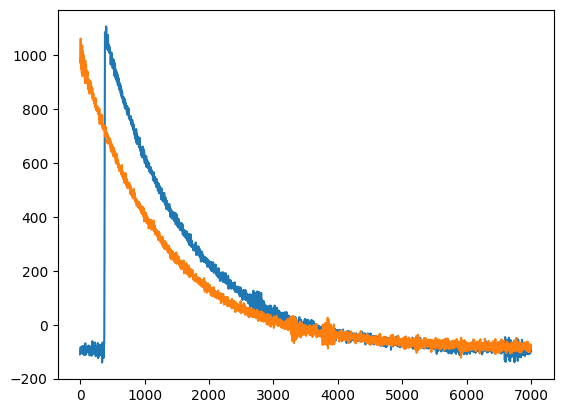

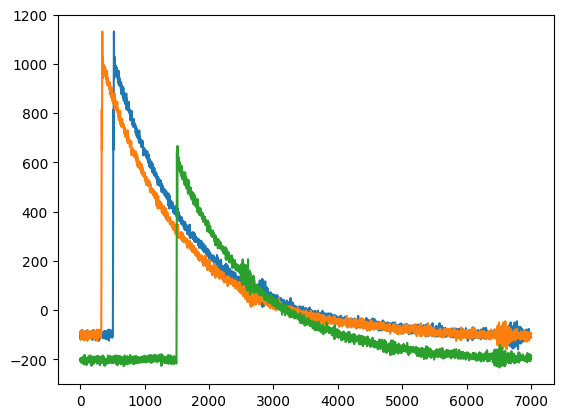

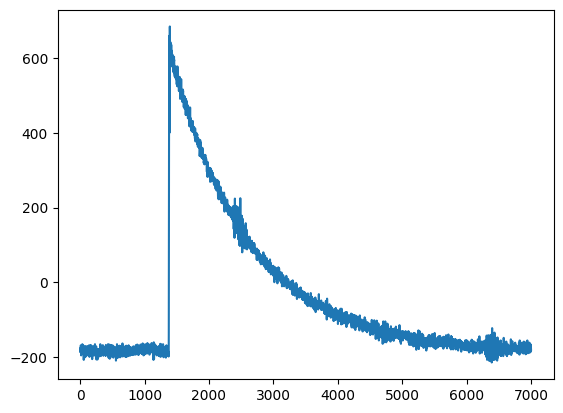

CPU times: user 4min 14s, sys: 47.8 s, total: 5min 2s
Wall time: 29min 6s


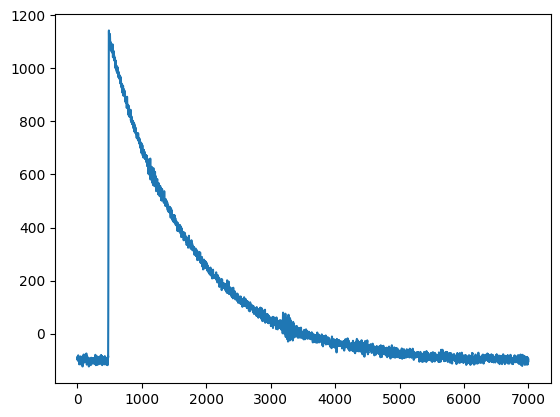

In [71]:
%%time 
risetime1374,time1374 = get_risetime(1374,pixel,low1374,high1374)

In [123]:
def gaussian(x,*pars):
    return pars[0]*np.exp(-1.0*((x-pars[1])/pars[2])**2.0)

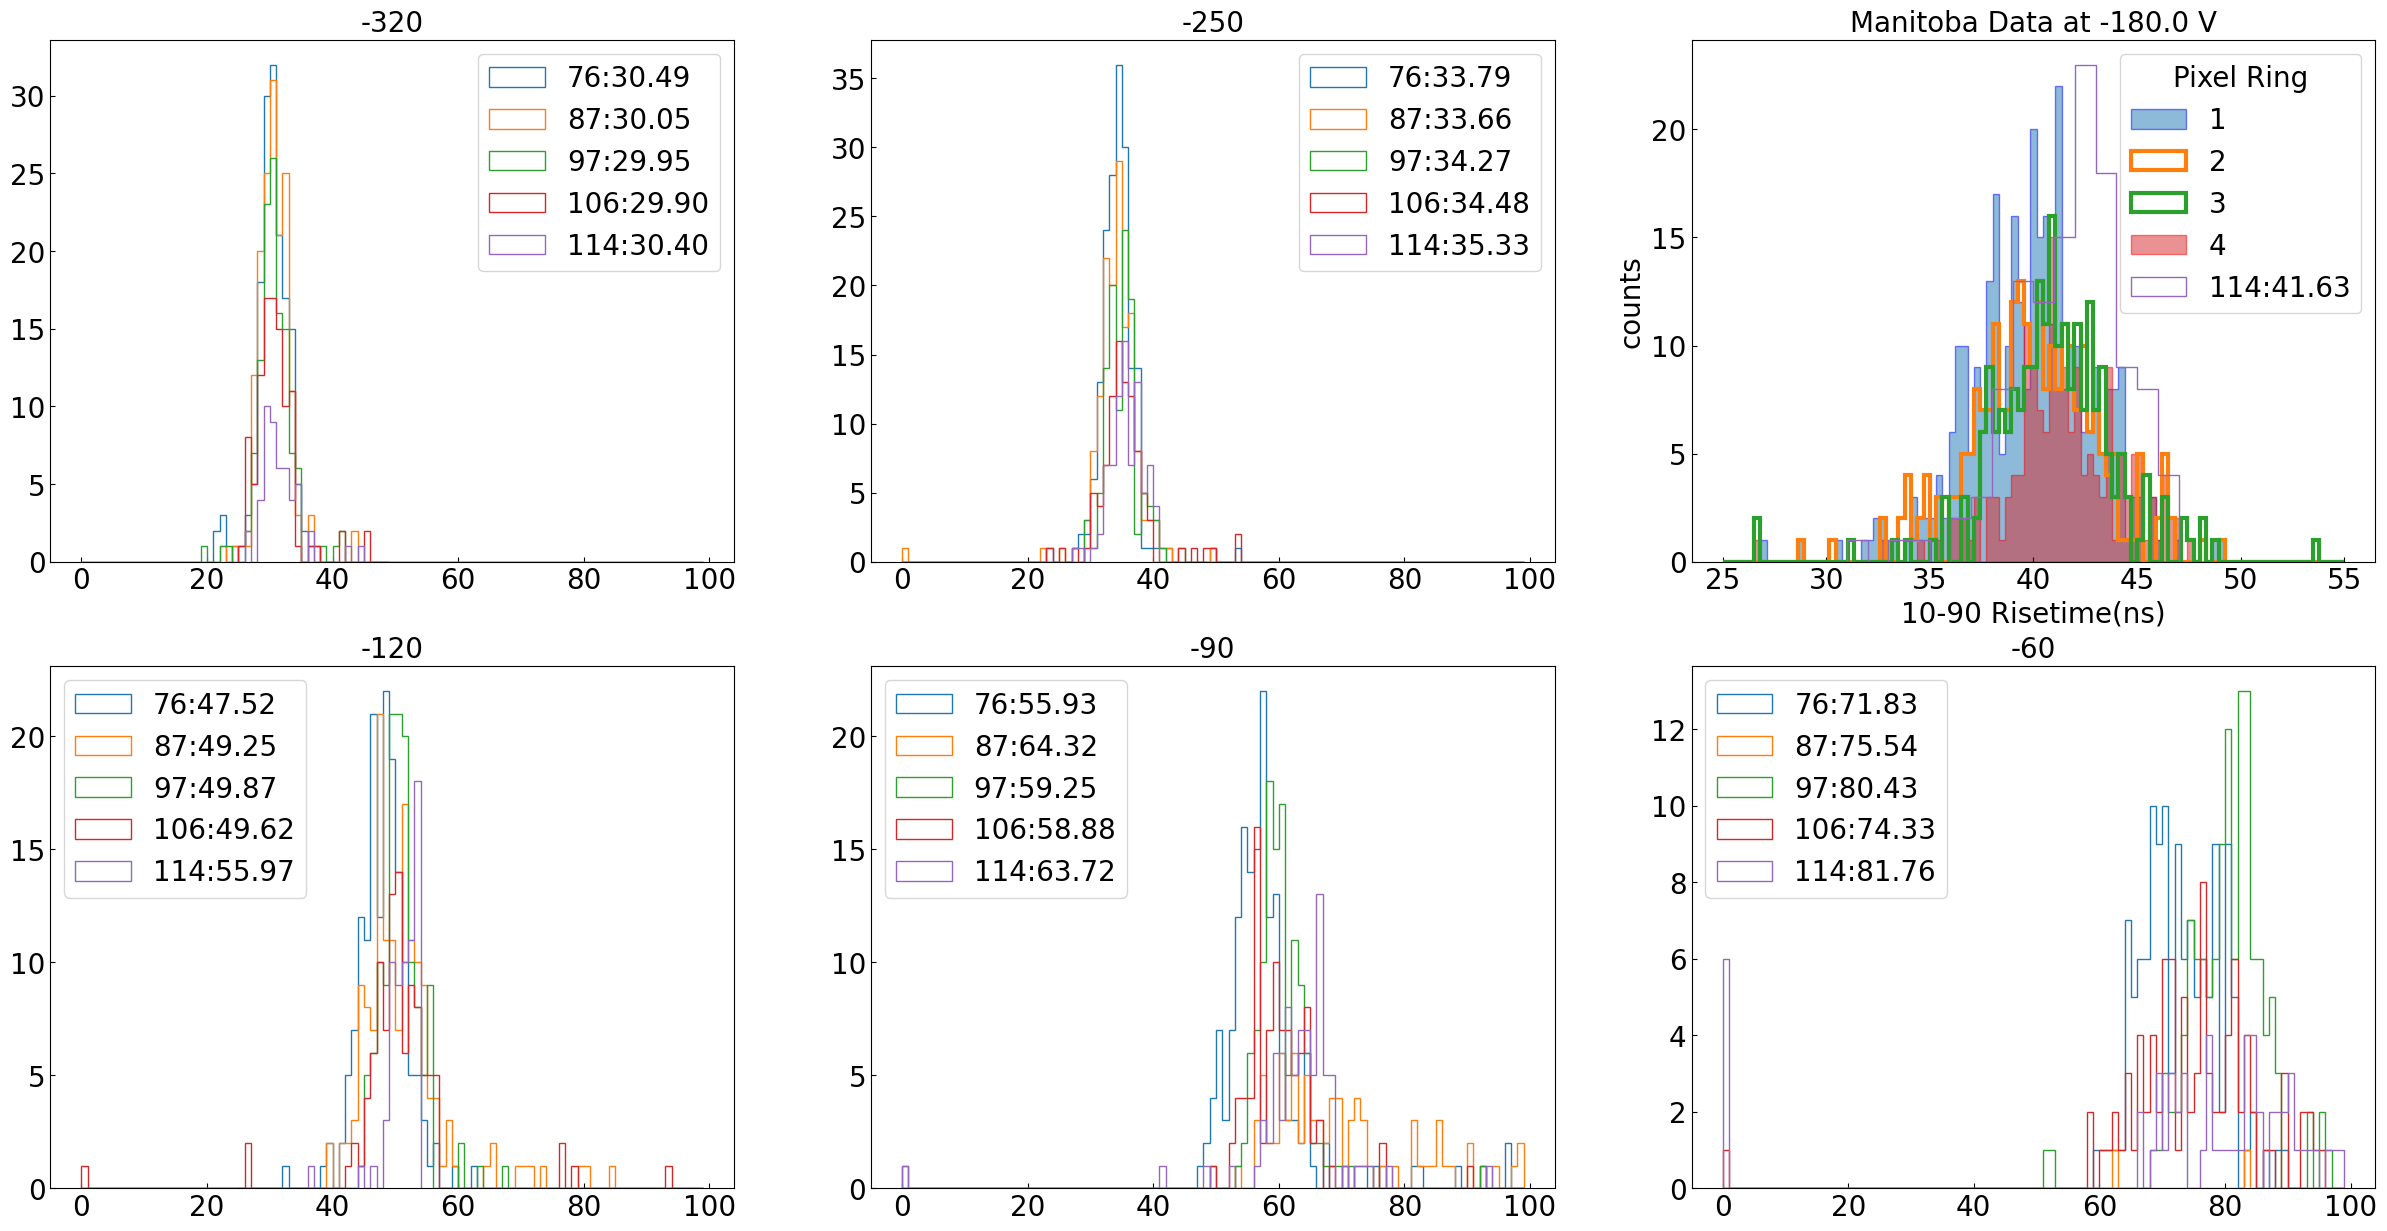

In [126]:
nrows,ncols=10,3
py.figure(figsize=(10*ncols,8*nrows))

peaks76 = []
peaks87 = []
peaks97 = []
peaks106 = []
peaks114 = []

ax=py.subplot(nrows,ncols,1)
ax.tick_params(direction='in',which='both',axis='both',labelsize=20)
ax.set_title('%d'%bias[0],size=20)
y,x = np.histogram(risetime1389[0],bins = np.linspace(25,45,100))
x = np.linspace(25,45,99)
params, err = curve_fit(gaussian,x,y,p0 = [18,30,3])

peaks76.append([params[1],np.sqrt(np.diag(err))])
ax.hist(risetime1389[0],bins=np.arange(0,100),histtype='step', label = '%d:%.2f'%(pixel[0],params[1]))

y,x = np.histogram(risetime1389[1],bins = np.arange(0,100))
x = np.arange(0,99)
params, err = curve_fit(gaussian,x,y,p0 = [18,30,3])
peaks87.append([params[1],np.sqrt(np.diag(err))])
ax.hist(risetime1389[1],bins=np.arange(0,100),histtype='step', label = '%d:%.2f'%(pixel[1],params[1]))

y,x = np.histogram(risetime1389[2],bins = np.arange(0,100))
x = np.arange(0,99)
params, err = curve_fit(gaussian,x,y,p0 = [18,30,3])
peaks97.append([params[1],np.sqrt(np.diag(err))])
ax.hist(risetime1389[2],bins=np.arange(0,100),histtype='step', label = '%d:%.2f'%(pixel[2],params[1]))

y,x = np.histogram(risetime1389[3],bins = np.arange(0,100))
x = np.arange(0,99)
params, err = curve_fit(gaussian,x,y,p0 = [18,30,3])
peaks106.append([params[1],np.sqrt(np.diag(err))])
ax.hist(risetime1389[3],bins=np.arange(25,50),histtype='step', label = '%d:%.2f'%(pixel[3],params[1]))

y,x = np.histogram(risetime1389[4],bins = np.arange(0,100))
x = np.arange(0,99)
params, err = curve_fit(gaussian,x,y,p0 = [18,30,3])
peaks114.append([params[1],np.sqrt(np.diag(err))])
ax.hist(risetime1389[4],bins=np.arange(25,50),histtype='step', label = '%d:%.2f'%(pixel[4],params[1]))
ax.legend(loc="upper right",prop={'size':20})

ax=py.subplot(nrows,ncols,2)
ax.set_title('%d'%bias[2],size=20)
ax.tick_params(direction='in',which='both',axis='both',labelsize=20)
y,x = np.histogram(risetime1391[0],bins = np.arange(0,100))
x = np.arange(0,99)
params, err = curve_fit(gaussian,x,y,p0 = [18,35,3])
peaks76.append([params[1],np.sqrt(np.diag(err))])
ax.hist(risetime1391[0],bins=np.arange(0,100),histtype='step', label = '%d:%.2f'%(pixel[0],params[1]))

y,x = np.histogram(risetime1391[1],bins = np.arange(0,100))
x = np.arange(0,99)
params, err = curve_fit(gaussian,x,y,p0 = [12,35,3])
peaks87.append([params[1],np.sqrt(np.diag(err))])
ax.hist(risetime1391[1],bins=np.arange(0,100),histtype='step', label = '%d:%.2f'%(pixel[1],params[1]))

y,x = np.histogram(risetime1391[2],bins = np.arange(0,100))
x = np.arange(0,99)
params, err = curve_fit(gaussian,x,y,p0 = [8,37,3])
peaks97.append([params[1],np.sqrt(np.diag(err))])
ax.hist(risetime1391[2],bins=np.arange(0,100),histtype='step', label = '%d:%.2f'%(pixel[2],params[1]))

y,x = np.histogram(risetime1391[3],bins = np.arange(0,100))
x = np.arange(0,99)
params, err = curve_fit(gaussian,x,y,p0 = [8,37,3])
peaks106.append([params[1],np.sqrt(np.diag(err))])
ax.hist(risetime1391[3],bins=np.arange(0,100),histtype='step', label = '%d:%.2f'%(pixel[3],params[1]))

y,x = np.histogram(risetime1391[4],bins = np.arange(0,100))
x = np.arange(0,99)
params, err = curve_fit(gaussian,x,y,p0 = [18,37,3])
peaks114.append([params[1],np.sqrt(np.diag(err))])
ax.hist(risetime1391[4],bins=np.arange(0,100),histtype='step', label = '%d:%.2f'%(pixel[4],params[1]))
ax.legend(loc="upper right",prop={'size':20})

ax=py.subplot(nrows,ncols,3)
ax.set_title('Manitoba Data at %d.0 V'%bias[3],size=20)
ax.set_ylabel('counts',size=20)
ax.set_xlabel('10-90 Risetime(ns)',size=20)
ax.tick_params(direction='in',which='both',axis='both',labelsize=20)

y,x = np.histogram(risetime1392[0],bins = np.linspace(25,55,100))
x = np.linspace(25,55,99)
params, err = curve_fit(gaussian,x,y,p0 = [20,40,3])
peaks76.append([params[1],np.sqrt(np.diag(err))])
ax.hist(risetime1392[0],bins=np.linspace(25,55,100), histtype='stepfilled',edgecolor='blue',linewidth = 1.,label = '1',alpha = 0.5)

y,x = np.histogram(risetime1392[1],bins = np.linspace(25,55,100))
x = np.linspace(25,55,99)
params, err = curve_fit(gaussian,x,y,p0 = [20,40,3])
peaks87.append([params[1],np.sqrt(np.diag(err))])
ax.hist(risetime1392[1],bins=np.linspace(25,55,100),histtype='step', linewidth = 3,label = '2')

y,x = np.histogram(risetime1392[2],bins = np.linspace(25,55,100))
x = np.linspace(25,55,99)
params, err = curve_fit(gaussian,x,y,p0 = [15,40,3])
peaks97.append([params[1],np.sqrt(np.diag(err))])
ax.hist(risetime1392[2],bins=np.linspace(25,55,100),histtype='step', linewidth = 3,label = '3')

y,x = np.histogram(risetime1392[3],bins = np.linspace(25,55,100))
x = np.linspace(25,55,99)
params, err = curve_fit(gaussian,x,y,p0 = [12,40,3])
peaks106.append([params[1],np.sqrt(np.diag(err))])
ax.hist(risetime1392[3],bins=np.linspace(25,55,100), label = '4',alpha = 0.5,linewidth = 1,histtype='stepfilled',edgecolor='red',)

y,x = np.histogram(risetime1392[4],bins = np.arange(25,55))
x = np.arange(25,54)
params, err = curve_fit(gaussian,x,y,p0 = [10,40,3])
peaks114.append([params[1],np.sqrt(np.diag(err))])
ax.hist(risetime1392[4],bins=np.arange(25,55),histtype='step', label = '%d:%.2f'%(pixel[4],params[1]))
ax.legend(loc="upper right", title = 'Pixel Ring', prop={'size':20},title_fontsize=20)


ax=py.subplot(nrows,ncols,4)
ax.set_title('%d'%bias[4],size=20)
ax.tick_params(direction='in',which='both',axis='both',labelsize=20)

y,x = np.histogram(risetime1393[0],bins = np.arange(25,55))
x = np.arange(25,54)
params, err = curve_fit(gaussian,x,y,p0 = [20,50,3])
peaks76.append([params[1],np.sqrt(np.diag(err))])
ax.hist(risetime1393[0],bins=np.arange(0,100),histtype='step', label = '%d:%.2f'%(pixel[0],params[1]))

y,x = np.histogram(risetime1393[1],bins = np.arange(25,55))
x = np.arange(25,54)
params, err = curve_fit(gaussian,x,y,p0 = [20,50,3])
peaks87.append([params[1],np.sqrt(np.diag(err))])
ax.hist(risetime1393[1],bins=np.arange(0,100),histtype='step', label = '%d:%.2f'%(pixel[1],params[1]))

y,x = np.histogram(risetime1393[2],bins = np.arange(25,55))
x = np.arange(25,54)
params, err = curve_fit(gaussian,x,y,p0 = [10,50,3])
peaks97.append([params[1],np.sqrt(np.diag(err))])
ax.hist(risetime1393[2],bins=np.arange(0,100),histtype='step', label = '%d:%.2f'%(pixel[2],params[1]))

y,x = np.histogram(risetime1393[3],bins = np.arange(25,55))
x = np.arange(25,54)
params, err = curve_fit(gaussian,x,y,p0 = [10,50,3])
peaks106.append([params[1],np.sqrt(np.diag(err))])
ax.hist(risetime1393[3],bins=np.arange(0,100),histtype='step', label = '%d:%.2f'%(pixel[3],params[1]))

y,x = np.histogram(risetime1393[4],bins = np.arange(25,55))
x = np.arange(25,54)
params, err = curve_fit(gaussian,x,y,p0 = [10,50,3])
peaks114.append([params[1],np.sqrt(np.diag(err))])
ax.hist(risetime1393[4],bins=np.arange(25,55),histtype='step', label = '%d:%.2f'%(pixel[4],params[1]))
ax.legend(loc="upper left",prop={'size':20})

ax=py.subplot(nrows,ncols,5)
ax.set_title('%d'%bias[5],size=20)
ax.tick_params(direction='in',which='both',axis='both',labelsize=20)
y,x = np.histogram(risetime1395[0],bins = np.arange(0,100))
x = np.arange(0,99)
params, err = curve_fit(gaussian,x,y,p0 = [20,60,3])
peaks76.append([params[1],np.sqrt(np.diag(err))])
ax.hist(risetime1395[0],bins=np.arange(0,100),histtype='step', label = '%d:%.2f'%(pixel[0],params[1]))

y,x = np.histogram(risetime1395[1],bins = np.arange(0,100))
x = np.arange(0,99)
params, err = curve_fit(gaussian,x,y,p0 = [20,60,3])
peaks87.append([params[1],np.sqrt(np.diag(err))])
ax.hist(risetime1395[1],bins=np.arange(0,100),histtype='step', label = '%d:%.2f'%(pixel[1],params[1]))

y,x = np.histogram(risetime1395[2],bins = np.arange(0,100))
x = np.arange(0,99)
params, err = curve_fit(gaussian,x,y,p0 = [10,60,3])
peaks97.append([params[1],np.sqrt(np.diag(err))])
ax.hist(risetime1395[2],bins=np.arange(0,100),histtype='step', label = '%d:%.2f'%(pixel[2],params[1]))

y,x = np.histogram(risetime1395[3],bins = np.arange(0,100))
x = np.arange(0,99)
params, err = curve_fit(gaussian,x,y,p0 = [10,60,3])
peaks106.append([params[1],np.sqrt(np.diag(err))])
ax.hist(risetime1395[3],bins=np.arange(0,100),histtype='step', label = '%d:%.2f'%(pixel[3],params[1]))

y,x = np.histogram(risetime1395[4],bins = np.arange(0,100))
x = np.arange(0,99)
params, err = curve_fit(gaussian,x,y,p0 = [10,60,3])
peaks114.append([params[1],np.sqrt(np.diag(err))])
ax.hist(risetime1395[4],bins=np.arange(0,100),histtype='step', label = '%d:%.2f'%(pixel[4],params[1]))
ax.legend(loc="upper left",prop={'size':20})


ax=py.subplot(nrows,ncols,6)
ax.set_title('%d'%bias[6],size=20)
ax.tick_params(direction='in',which='both',axis='both',labelsize=20)
y,x = np.histogram(risetime1399[0],bins = np.arange(0,100))
x = np.arange(0,99)
params, err = curve_fit(gaussian,x,y,p0 = [20,80,3])
peaks76.append([params[1],np.sqrt(np.diag(err))])
ax.hist(risetime1399[0],bins=np.arange(0,100),histtype='step', label = '%d:%.2f'%(pixel[0],params[1]))

y,x = np.histogram(risetime1399[1],bins = np.arange(0,100))
x = np.arange(0,99)
params, err = curve_fit(gaussian,x,y,p0 = [20,80,3])
peaks87.append([params[1],np.sqrt(np.diag(err))])
ax.hist(risetime1399[1],bins=np.arange(0,100),histtype='step', label = '%d:%.2f'%(pixel[1],params[1]))

y,x = np.histogram(risetime1399[2],bins = np.arange(0,100))
x = np.arange(0,99)
params, err = curve_fit(gaussian,x,y,p0 = [10,80,3])
peaks97.append([params[1],np.sqrt(np.diag(err))])
ax.hist(risetime1399[2],bins=np.arange(0,100),histtype='step', label = '%d:%.2f'%(pixel[2],params[1]))

y,x = np.histogram(risetime1399[3],bins = np.arange(0,100))
x = np.arange(0,99)
params, err = curve_fit(gaussian,x,y,p0 = [10,80,3])
peaks106.append([params[1],np.sqrt(np.diag(err))])
ax.hist(risetime1399[3],bins=np.arange(0,100),histtype='step', label = '%d:%.2f'%(pixel[3],params[1]))

y,x = np.histogram(risetime1399[4],bins = np.arange(0,100))
x = np.arange(0,99)
params, err = curve_fit(gaussian,x,y,p0 = [10,80,3])
peaks114.append([params[1],np.sqrt(np.diag(err))[1]])
ax.hist(risetime1399[4],bins=np.arange(0,100),histtype='step', label = '%d:%.2f'%(pixel[4],params[1]))
ax.legend(loc="upper left",prop={'size':20})
plt.show()

In [127]:
peaks76

[[np.float64(30.487836065442195), array([0.44199229, 0.158688  , 0.22476489])],
 [np.float64(33.79250748155416), array([0.5850732 , 0.04014543, 0.05677422])],
 [np.float64(39.986416295923156), array([0.63818699, 0.15007339, 0.21223582])],
 [np.float64(47.51991558831792), array([1.01661236, 0.19728367, 0.29356977])],
 [np.float64(55.929953578434606), array([0.58964331, 0.13553639, 0.19167739])],
 [np.float64(71.82534502590224), array([0.42381244, 0.40894568, 0.57833767])]]

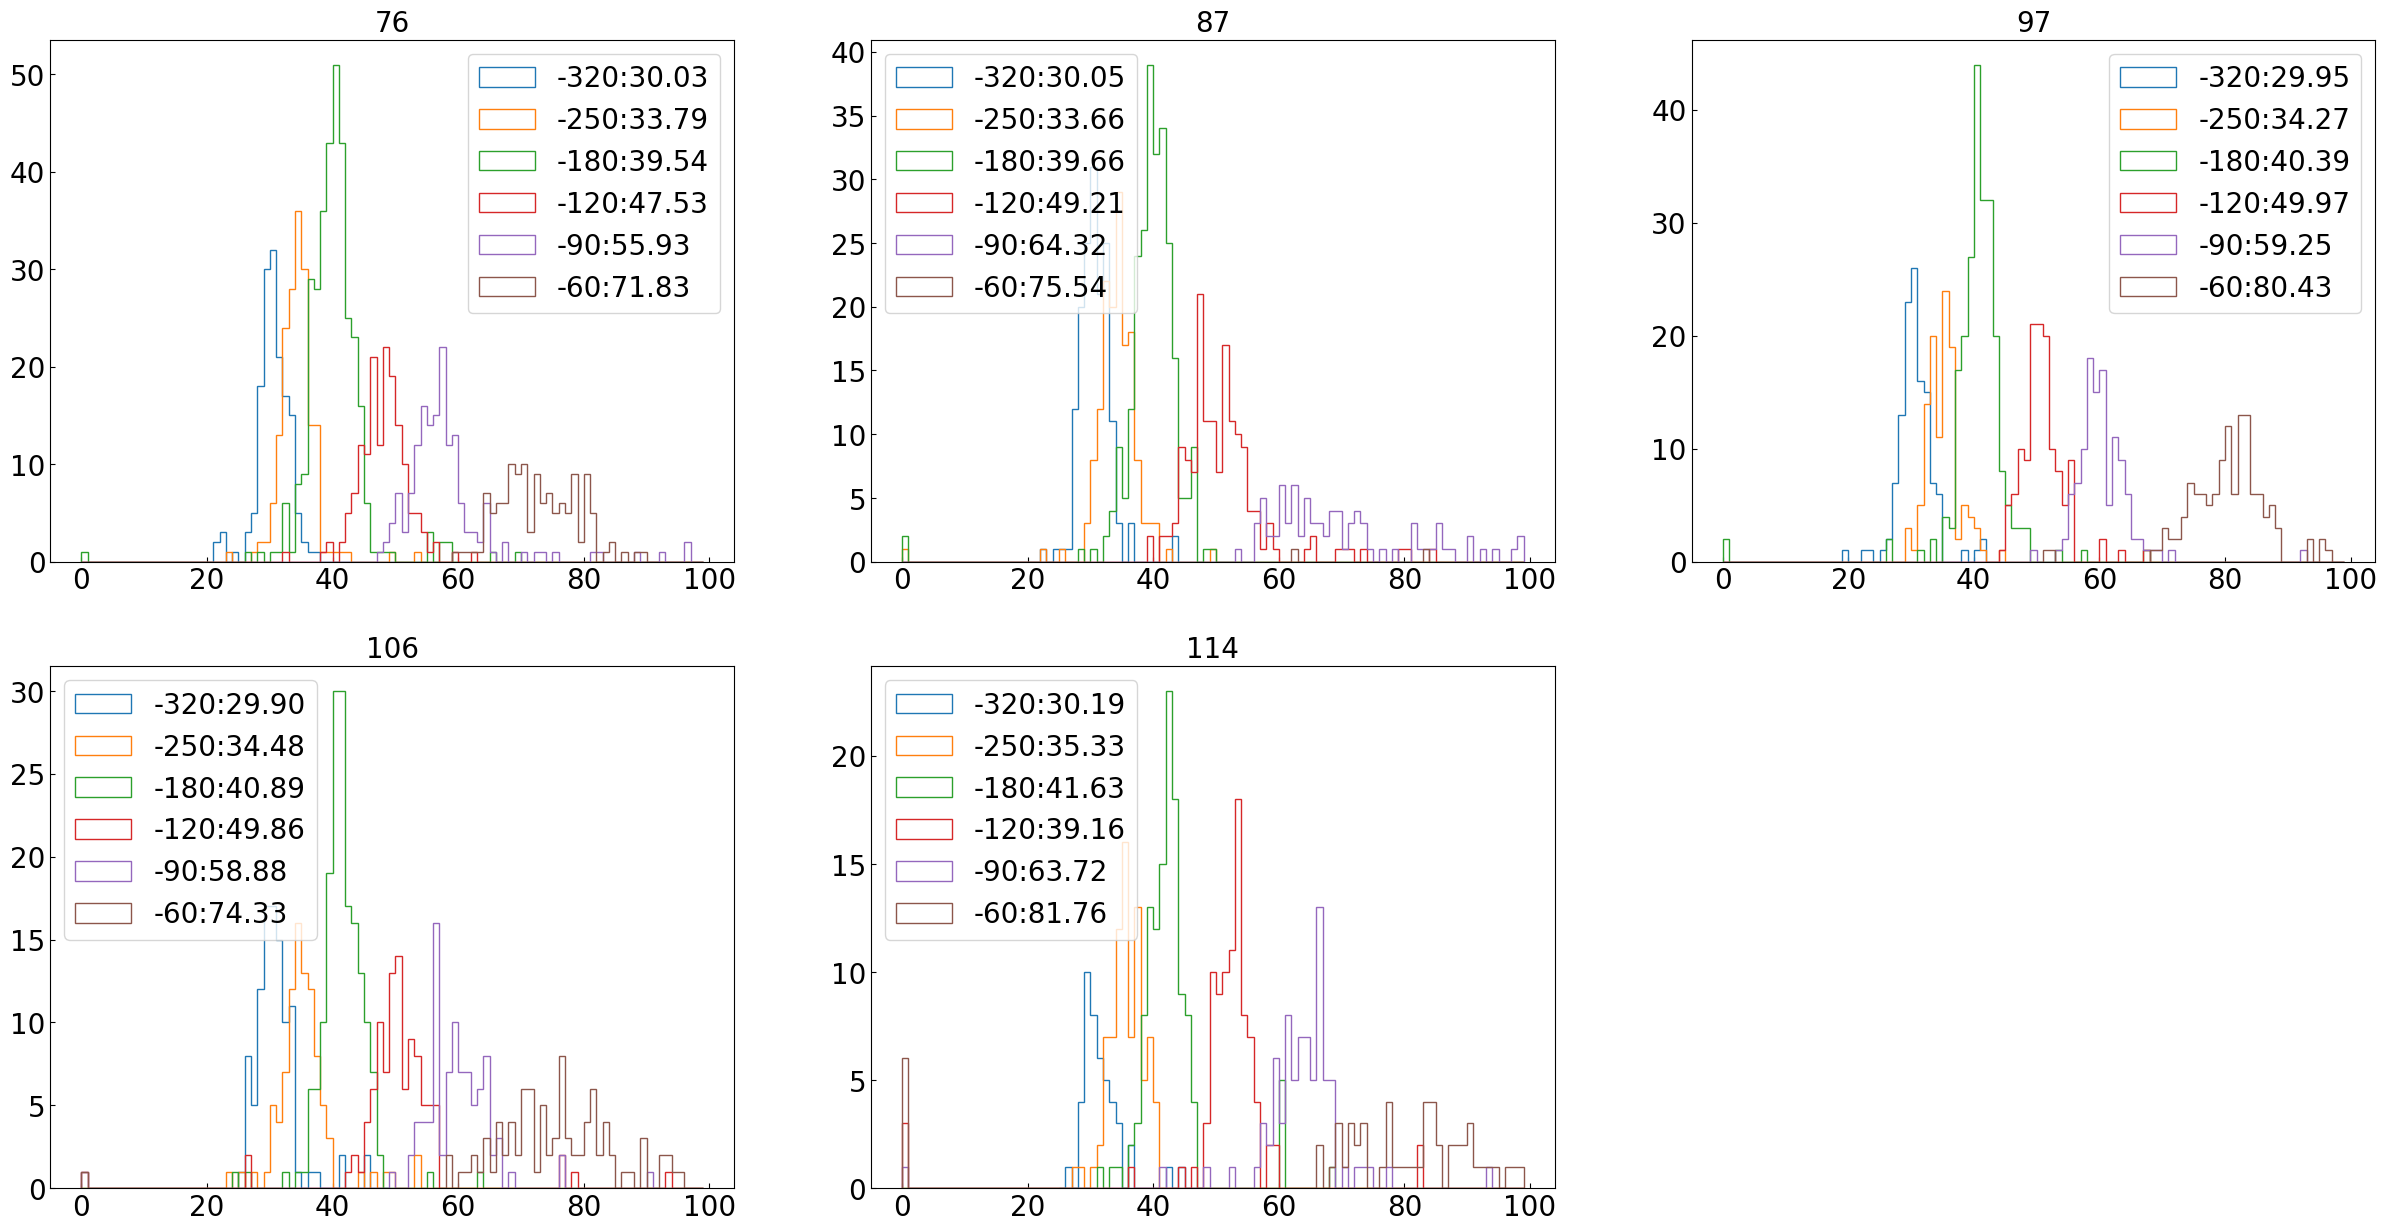

In [46]:
nrows,ncols=10,3
py.figure(figsize=(10*ncols,8*nrows))

ax=py.subplot(nrows,ncols,1)
ax.tick_params(direction='in',which='both',axis='both',labelsize=20)
ax.set_title('%d'%pixel[0],size=20)
y,x = np.histogram(risetime1389[0],bins = np.arange(0,100))
x = np.arange(0,99)
params, err = curve_fit(gaussian,x,y,p0 = [18,30,3])
ax.hist(risetime1389[0],bins=np.arange(0,100),histtype='step', label = '%d:%.2f'%(bias[0],params[1]))

y,x = np.histogram(risetime1391[0],bins = np.arange(0,100))
x = np.arange(0,99)
params, err = curve_fit(gaussian,x,y,p0 = [18,35,3])
ax.hist(risetime1391[0],bins=np.arange(0,100),histtype='step', label = '%d:%.2f'%(bias[2],params[1]))

y,x = np.histogram(risetime1392[0],bins = np.arange(0,100))
x = np.arange(0,99)
params, err = curve_fit(gaussian,x,y,p0 = [20,40,3])
ax.hist(risetime1392[0],bins=np.arange(0,100),histtype='step', label = '%d:%.2f'%(bias[3],params[1]))

y,x = np.histogram(risetime1393[0],bins = np.arange(0,100))
x = np.arange(0,99)
params, err = curve_fit(gaussian,x,y,p0 = [20,50,3])
ax.hist(risetime1393[0],bins=np.arange(0,100),histtype='step', label = '%d:%.2f'%(bias[4],params[1]))

y,x = np.histogram(risetime1395[0],bins = np.arange(0,100))
x = np.arange(0,99)
params, err = curve_fit(gaussian,x,y,p0 = [20,60,3])
ax.hist(risetime1395[0],bins=np.arange(0,100),histtype='step', label = '%d:%.2f'%(bias[5],params[1]))

y,x = np.histogram(risetime1399[0],bins = np.arange(0,100))
x = np.arange(0,99)
params, err = curve_fit(gaussian,x,y,p0 = [20,80,3])
ax.hist(risetime1399[0],bins=np.arange(0,100),histtype='step', label = '%d:%.2f'%(bias[6],params[1]))
ax.legend(loc="upper right",prop={'size':20})


ax=py.subplot(nrows,ncols,2)
ax.tick_params(direction='in',which='both',axis='both',labelsize=20)
ax.set_title('%d'%pixel[1],size=20)
y,x = np.histogram(risetime1389[1],bins = np.arange(0,100))
x = np.arange(0,99)
params, err = curve_fit(gaussian,x,y,p0 = [18,30,3])
ax.hist(risetime1389[1],bins=np.arange(0,100),histtype='step', label = '%d:%.2f'%(bias[0],params[1]))

y,x = np.histogram(risetime1391[1],bins = np.arange(0,100))
x = np.arange(0,99)
params, err = curve_fit(gaussian,x,y,p0 = [12,35,3])
ax.hist(risetime1391[1],bins=np.arange(0,100),histtype='step', label = '%d:%.2f'%(bias[2],params[1]))

y,x = np.histogram(risetime1392[1],bins = np.arange(0,100))
x = np.arange(0,99)
params, err = curve_fit(gaussian,x,y,p0 = [20,40,3])
ax.hist(risetime1392[1],bins=np.arange(0,100),histtype='step', label = '%d:%.2f'%(bias[3],params[1]))

y,x = np.histogram(risetime1393[1],bins = np.arange(0,100))
x = np.arange(0,99)
params, err = curve_fit(gaussian,x,y,p0 = [20,50,3])
ax.hist(risetime1393[1],bins=np.arange(0,100),histtype='step', label = '%d:%.2f'%(bias[4],params[1]))

y,x = np.histogram(risetime1395[1],bins = np.arange(0,100))
x = np.arange(0,99)
params, err = curve_fit(gaussian,x,y,p0 = [20,60,3])
ax.hist(risetime1395[1],bins=np.arange(0,100),histtype='step', label = '%d:%.2f'%(bias[5],params[1]))

y,x = np.histogram(risetime1399[1],bins = np.arange(0,100))
x = np.arange(0,99)
params, err = curve_fit(gaussian,x,y,p0 = [20,80,3])
ax.hist(risetime1399[1],bins=np.arange(0,100),histtype='step', label = '%d:%.2f'%(bias[6],params[1]))
ax.legend(loc="upper left",prop={'size':20})

ax=py.subplot(nrows,ncols,3)
ax.tick_params(direction='in',which='both',axis='both',labelsize=20)
ax.set_title('%d'%pixel[2],size=20)
y,x = np.histogram(risetime1389[2],bins = np.arange(0,100))
x = np.arange(0,99)
params, err = curve_fit(gaussian,x,y,p0 = [18,30,3])
ax.hist(risetime1389[2],bins=np.arange(0,100),histtype='step', label = '%d:%.2f'%(bias[0],params[1]))

y,x = np.histogram(risetime1391[2],bins = np.arange(0,100))
x = np.arange(0,99)
params, err = curve_fit(gaussian,x,y,p0 = [8,37,3])
ax.hist(risetime1391[2],bins=np.arange(0,100),histtype='step', label = '%d:%.2f'%(bias[2],params[1]))

y,x = np.histogram(risetime1392[2],bins = np.arange(0,100))
x = np.arange(0,99)
params, err = curve_fit(gaussian,x,y,p0 = [15,40,3])
ax.hist(risetime1392[2],bins=np.arange(0,100),histtype='step', label = '%d:%.2f'%(bias[3],params[1]))

y,x = np.histogram(risetime1393[2],bins = np.arange(0,100))
x = np.arange(0,99)
params, err = curve_fit(gaussian,x,y,p0 = [10,50,3])
ax.hist(risetime1393[2],bins=np.arange(0,100),histtype='step', label = '%d:%.2f'%(bias[4],params[1]))

y,x = np.histogram(risetime1395[2],bins = np.arange(0,100))
x = np.arange(0,99)
params, err = curve_fit(gaussian,x,y,p0 = [10,60,3])
ax.hist(risetime1395[2],bins=np.arange(0,100),histtype='step', label = '%d:%.2f'%(bias[5],params[1]))

y,x = np.histogram(risetime1399[2],bins = np.arange(0,100))
x = np.arange(0,99)
params, err = curve_fit(gaussian,x,y,p0 = [10,80,3])
ax.hist(risetime1399[2],bins=np.arange(0,100),histtype='step', label = '%d:%.2f'%(bias[6],params[1]))
ax.legend(loc="upper right",prop={'size':20})


ax=py.subplot(nrows,ncols,4)
ax.tick_params(direction='in',which='both',axis='both',labelsize=20)
ax.set_title('%d'%pixel[3],size=20)
y,x = np.histogram(risetime1389[3],bins = np.arange(0,100))
x = np.arange(0,99)
params, err = curve_fit(gaussian,x,y,p0 = [18,30,3])
ax.hist(risetime1389[3],bins=np.arange(25,50),histtype='step', label = '%d:%.2f'%(bias[0],params[1]))

y,x = np.histogram(risetime1391[3],bins = np.arange(0,100))
x = np.arange(0,99)
params, err = curve_fit(gaussian,x,y,p0 = [8,37,3])
ax.hist(risetime1391[3],bins=np.arange(0,100),histtype='step', label = '%d:%.2f'%(bias[2],params[1]))

y,x = np.histogram(risetime1392[3],bins = np.arange(0,100))
x = np.arange(0,99)
params, err = curve_fit(gaussian,x,y,p0 = [12,40,3])
ax.hist(risetime1392[3],bins=np.arange(0,100),histtype='step', label = '%d:%.2f'%(bias[3],params[1]))

y,x = np.histogram(risetime1393[3],bins = np.arange(0,100))
x = np.arange(0,99)
params, err = curve_fit(gaussian,x,y,p0 = [10,50,3])
ax.hist(risetime1393[3],bins=np.arange(0,100),histtype='step', label = '%d:%.2f'%(bias[4],params[1]))

y,x = np.histogram(risetime1395[3],bins = np.arange(0,100))
x = np.arange(0,99)
params, err = curve_fit(gaussian,x,y,p0 = [10,60,3])
ax.hist(risetime1395[3],bins=np.arange(0,100),histtype='step', label = '%d:%.2f'%(bias[5],params[1]))

y,x = np.histogram(risetime1399[3],bins = np.arange(0,100))
x = np.arange(0,99)
params, err = curve_fit(gaussian,x,y,p0 = [10,80,3])
ax.hist(risetime1399[3],bins=np.arange(0,100),histtype='step', label = '%d:%.2f'%(bias[6],params[1]))
ax.legend(loc="upper left",prop={'size':20})

ax=py.subplot(nrows,ncols,5)
ax.tick_params(direction='in',which='both',axis='both',labelsize=20)
ax.set_title('%d'%pixel[4],size=20)
y,x = np.histogram(risetime1389[4],bins = np.arange(0,100))
x = np.arange(0,99)
params, err = curve_fit(gaussian,x,y,p0 = [18,30,3])
ax.hist(risetime1389[4],bins=np.arange(25,50),histtype='step', label = '%d:%.2f'%(bias[0],params[1]))

y,x = np.histogram(risetime1391[4],bins = np.arange(0,100))
x = np.arange(0,99)
params, err = curve_fit(gaussian,x,y,p0 = [18,37,3])
ax.hist(risetime1391[4],bins=np.arange(0,100),histtype='step', label = '%d:%.2f'%(bias[2],params[1]))

y,x = np.histogram(risetime1392[4],bins = np.arange(0,100))
x = np.arange(0,99)
params, err = curve_fit(gaussian,x,y,p0 = [10,40,3])
ax.hist(risetime1392[4],bins=np.arange(0,100),histtype='step', label = '%d:%.2f'%(bias[3],params[1]))

y,x = np.histogram(risetime1393[4],bins = np.arange(0,100))
x = np.arange(0,99)
params, err = curve_fit(gaussian,x,y,p0 = [10,40,3])
ax.hist(risetime1393[4],bins=np.arange(0,100),histtype='step', label = '%d:%.2f'%(bias[4],params[1]))

y,x = np.histogram(risetime1395[4],bins = np.arange(0,100))
x = np.arange(0,99)
params, err = curve_fit(gaussian,x,y,p0 = [10,60,3])
ax.hist(risetime1395[4],bins=np.arange(0,100),histtype='step', label = '%d:%.2f'%(bias[5],params[1]))

y,x = np.histogram(risetime1399[4],bins = np.arange(0,100))
x = np.arange(0,99)
params, err = curve_fit(gaussian,x,y,p0 = [10,80,3])
ax.hist(risetime1399[4],bins=np.arange(0,100),histtype='step', label = '%d:%.2f'%(bias[6],params[1]))
ax.legend(loc="upper left",prop={'size':20})

plt.show()

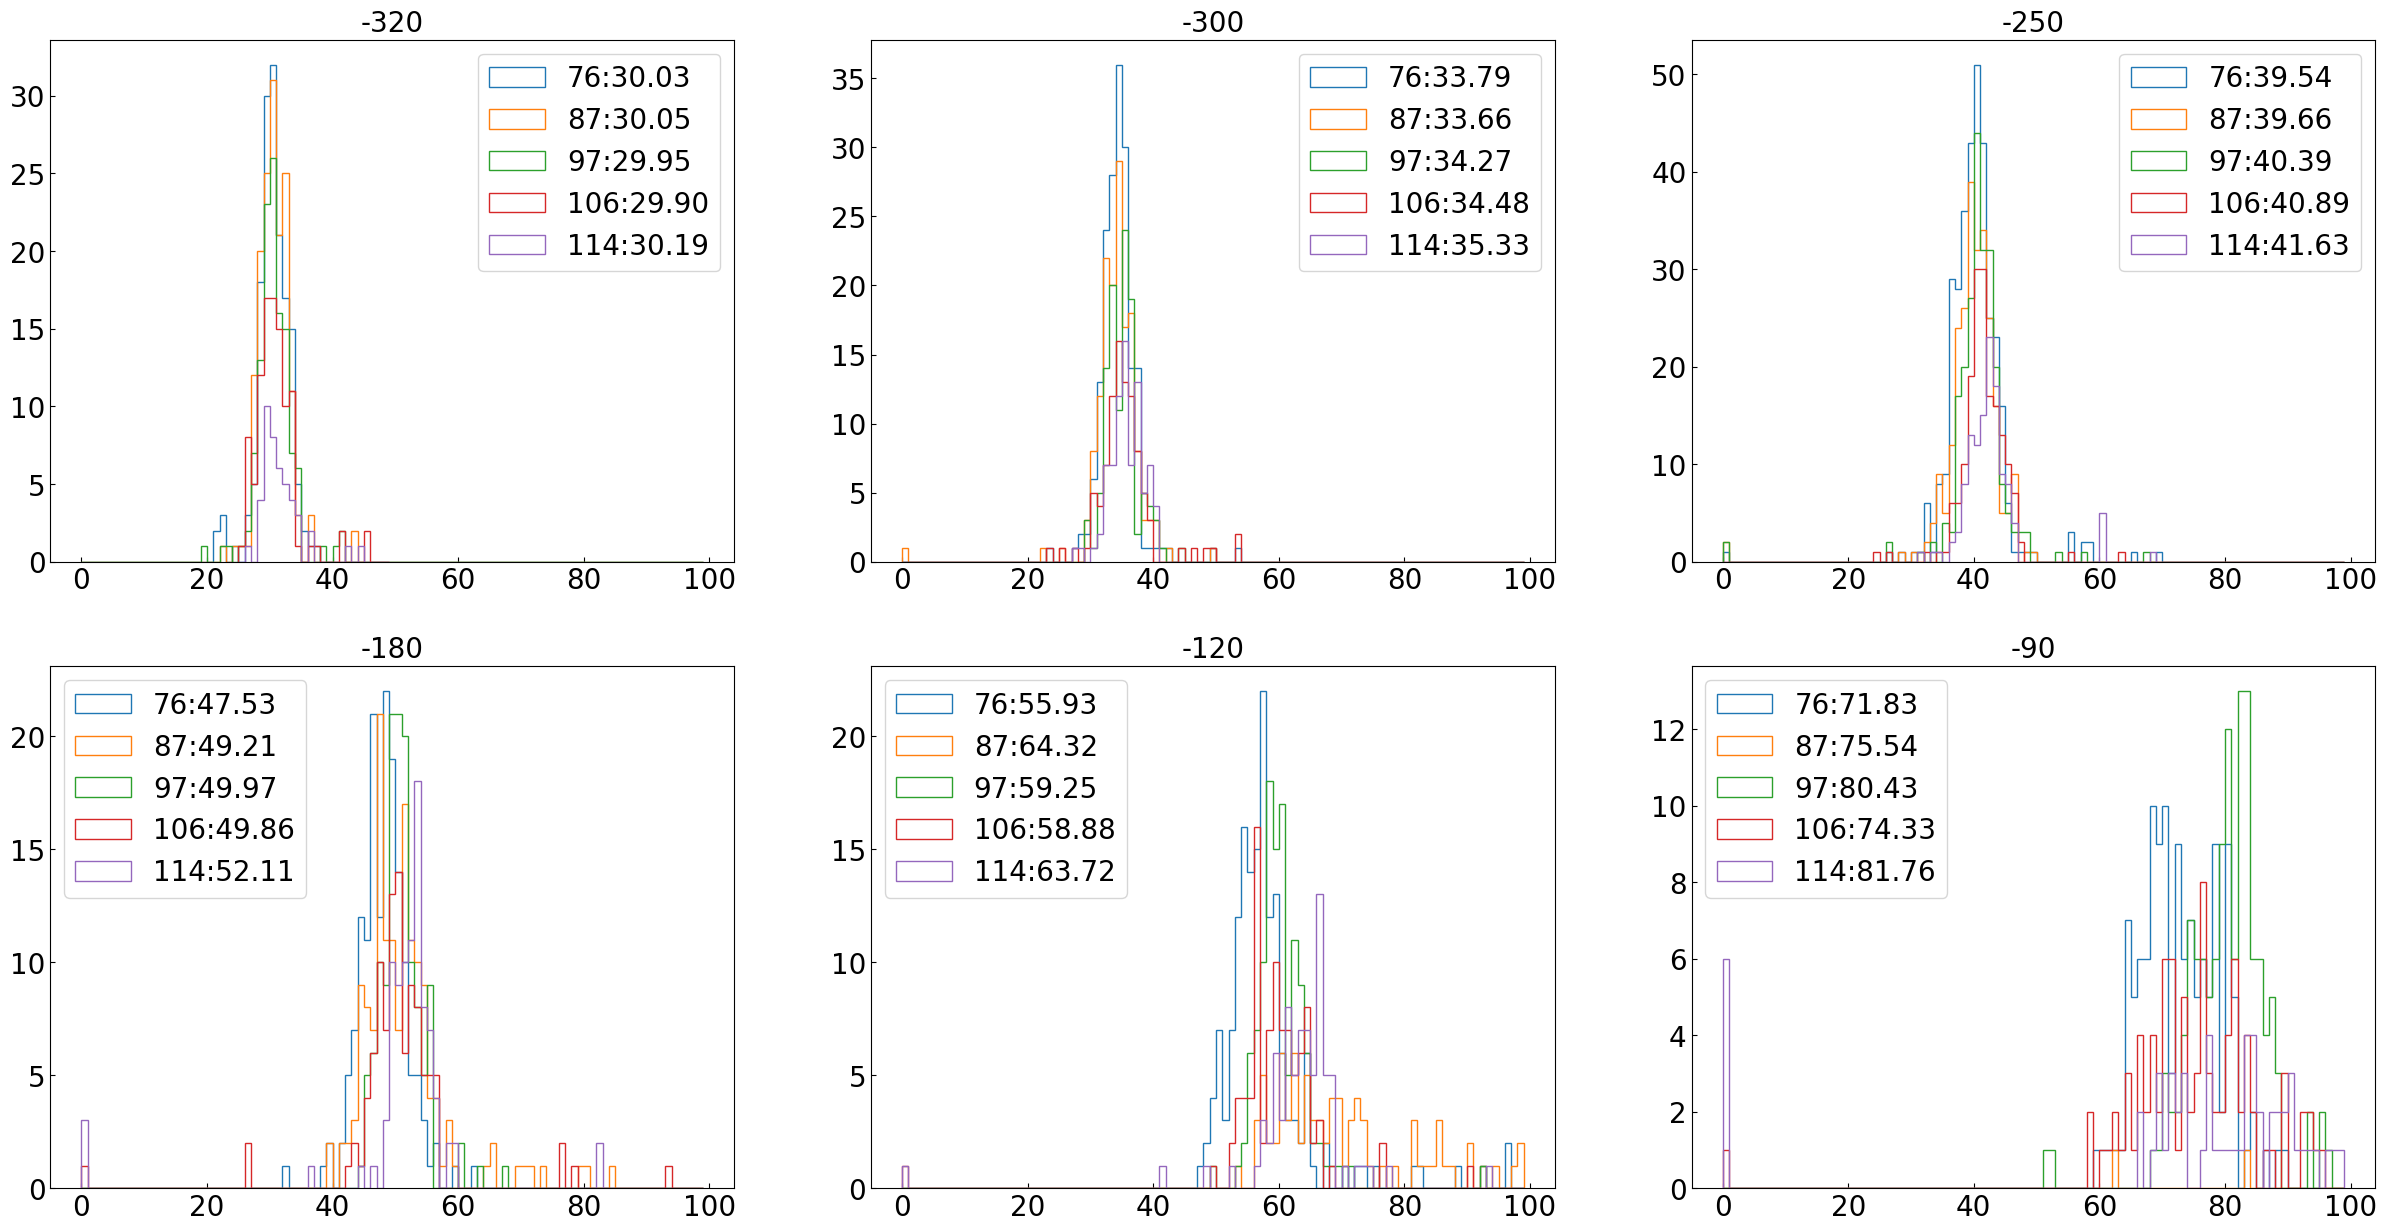

In [82]:
nrows,ncols=10,3
py.figure(figsize=(10*ncols,8*nrows))

ax=py.subplot(nrows,ncols,1)
ax.set_title('%d'%bias[0],size=20)
ax.tick_params(direction='in',which='both',axis='both',labelsize=20)
y,x = np.histogram(risetime1389[0],bins = np.arange(0,100))
x = np.arange(0,99)
params, err = curve_fit(gaussian,x,y,p0 = [18,30,3])
ax.hist(risetime1389[0],bins=np.arange(0,100),histtype='step', label = '%d:%.2f'%(pixel[0],params[1]))

y,x = np.histogram(risetime1389[1],bins = np.arange(0,100))
x = np.arange(0,99)
params, err = curve_fit(gaussian,x,y,p0 = [18,30,3])
ax.hist(risetime1389[1],bins=np.arange(0,100),histtype='step', label = '%d:%.2f'%(pixel[1],params[1]))

y,x = np.histogram(risetime1389[2],bins = np.arange(0,100))
x = np.arange(0,99)
params, err = curve_fit(gaussian,x,y,p0 = [18,30,3])
ax.hist(risetime1389[2],bins=np.arange(0,100),histtype='step', label = '%d:%.2f'%(pixel[2],params[1]))

y,x = np.histogram(risetime1389[3],bins = np.arange(0,100))
x = np.arange(0,99)
params, err = curve_fit(gaussian,x,y,p0 = [18,30,3])
ax.hist(risetime1389[3],bins=np.arange(25,50),histtype='step', label = '%d:%.2f'%(pixel[3],params[1]))

y,x = np.histogram(risetime1389[4],bins = np.arange(0,100))
x = np.arange(0,99)
params, err = curve_fit(gaussian,x,y,p0 = [18,30,3])
ax.hist(risetime1389[4],bins=np.arange(25,50),histtype='step', label = '%d:%.2f'%(pixel[4],params[1]))
ax.legend(loc="upper right",prop={'size':20})

ax=py.subplot(nrows,ncols,2)
ax.set_title('%d'%bias[1],size=20)
ax.tick_params(direction='in',which='both',axis='both',labelsize=20)
y,x = np.histogram(risetime1391[0],bins = np.arange(0,100))
x = np.arange(0,99)
params, err = curve_fit(gaussian,x,y,p0 = [18,35,3])
ax.hist(risetime1391[0],bins=np.arange(0,100),histtype='step', label = '%d:%.2f'%(pixel[0],params[1]))

y,x = np.histogram(risetime1391[1],bins = np.arange(0,100))
x = np.arange(0,99)
params, err = curve_fit(gaussian,x,y,p0 = [12,35,3])
ax.hist(risetime1391[1],bins=np.arange(0,100),histtype='step', label = '%d:%.2f'%(pixel[1],params[1]))

y,x = np.histogram(risetime1391[2],bins = np.arange(0,100))
x = np.arange(0,99)
params, err = curve_fit(gaussian,x,y,p0 = [8,37,3])
ax.hist(risetime1391[2],bins=np.arange(0,100),histtype='step', label = '%d:%.2f'%(pixel[2],params[1]))

y,x = np.histogram(risetime1391[3],bins = np.arange(0,100))
x = np.arange(0,99)
params, err = curve_fit(gaussian,x,y,p0 = [8,37,3])
ax.hist(risetime1391[3],bins=np.arange(0,100),histtype='step', label = '%d:%.2f'%(pixel[3],params[1]))

y,x = np.histogram(risetime1391[4],bins = np.arange(0,100))
x = np.arange(0,99)
params, err = curve_fit(gaussian,x,y,p0 = [18,37,3])
ax.hist(risetime1391[4],bins=np.arange(0,100),histtype='step', label = '%d:%.2f'%(pixel[4],params[1]))
ax.legend(loc="upper right",prop={'size':20})

ax=py.subplot(nrows,ncols,3)
ax.set_title('%d'%bias[2],size=20)
ax.tick_params(direction='in',which='both',axis='both',labelsize=20)

y,x = np.histogram(risetime1392[0],bins = np.arange(0,100))
x = np.arange(0,99)
params, err = curve_fit(gaussian,x,y,p0 = [20,40,3])
ax.hist(risetime1392[0],bins=np.arange(0,100),histtype='step', label = '%d:%.2f'%(pixel[0],params[1]))

y,x = np.histogram(risetime1392[1],bins = np.arange(0,100))
x = np.arange(0,99)
params, err = curve_fit(gaussian,x,y,p0 = [20,40,3])
ax.hist(risetime1392[1],bins=np.arange(0,100),histtype='step', label = '%d:%.2f'%(pixel[1],params[1]))

y,x = np.histogram(risetime1392[2],bins = np.arange(0,100))
x = np.arange(0,99)
params, err = curve_fit(gaussian,x,y,p0 = [15,40,3])
ax.hist(risetime1392[2],bins=np.arange(0,100),histtype='step', label = '%d:%.2f'%(pixel[2],params[1]))

y,x = np.histogram(risetime1392[3],bins = np.arange(0,100))
x = np.arange(0,99)
params, err = curve_fit(gaussian,x,y,p0 = [12,40,3])
ax.hist(risetime1392[3],bins=np.arange(0,100),histtype='step', label = '%d:%.2f'%(pixel[3],params[1]))

y,x = np.histogram(risetime1392[4],bins = np.arange(0,100))
x = np.arange(0,99)
params, err = curve_fit(gaussian,x,y,p0 = [10,40,3])
ax.hist(risetime1392[4],bins=np.arange(0,100),histtype='step', label = '%d:%.2f'%(pixel[4],params[1]))
ax.legend(loc="upper right",prop={'size':20})


ax=py.subplot(nrows,ncols,4)
ax.set_title('%d'%bias[3],size=20)
ax.tick_params(direction='in',which='both',axis='both',labelsize=20)

y,x = np.histogram(risetime1393[0],bins = np.arange(0,100))
x = np.arange(0,99)
params, err = curve_fit(gaussian,x,y,p0 = [20,50,3])
ax.hist(risetime1393[0],bins=np.arange(0,100),histtype='step', label = '%d:%.2f'%(pixel[0],params[1]))

y,x = np.histogram(risetime1393[1],bins = np.arange(0,100))
x = np.arange(0,99)
params, err = curve_fit(gaussian,x,y,p0 = [20,50,3])
ax.hist(risetime1393[1],bins=np.arange(0,100),histtype='step', label = '%d:%.2f'%(pixel[1],params[1]))

y,x = np.histogram(risetime1393[2],bins = np.arange(0,100))
x = np.arange(0,99)
params, err = curve_fit(gaussian,x,y,p0 = [10,50,3])
ax.hist(risetime1393[2],bins=np.arange(0,100),histtype='step', label = '%d:%.2f'%(pixel[2],params[1]))

y,x = np.histogram(risetime1393[3],bins = np.arange(0,100))
x = np.arange(0,99)
params, err = curve_fit(gaussian,x,y,p0 = [10,50,3])
ax.hist(risetime1393[3],bins=np.arange(0,100),histtype='step', label = '%d:%.2f'%(pixel[3],params[1]))

y,x = np.histogram(risetime1393[4],bins = np.arange(0,100))
x = np.arange(0,99)
params, err = curve_fit(gaussian,x,y,p0 = [10,50,3])
ax.hist(risetime1393[4],bins=np.arange(0,100),histtype='step', label = '%d:%.2f'%(pixel[4],params[1]))
ax.legend(loc="upper left",prop={'size':20})

ax=py.subplot(nrows,ncols,5)
ax.set_title('%d'%bias[4],size=20)
ax.tick_params(direction='in',which='both',axis='both',labelsize=20)
y,x = np.histogram(risetime1395[0],bins = np.arange(0,100))
x = np.arange(0,99)
params, err = curve_fit(gaussian,x,y,p0 = [20,60,3])
ax.hist(risetime1395[0],bins=np.arange(0,100),histtype='step', label = '%d:%.2f'%(pixel[0],params[1]))

y,x = np.histogram(risetime1395[1],bins = np.arange(0,100))
x = np.arange(0,99)
params, err = curve_fit(gaussian,x,y,p0 = [20,60,3])
ax.hist(risetime1395[1],bins=np.arange(0,100),histtype='step', label = '%d:%.2f'%(pixel[1],params[1]))

y,x = np.histogram(risetime1395[2],bins = np.arange(0,100))
x = np.arange(0,99)
params, err = curve_fit(gaussian,x,y,p0 = [10,60,3])
ax.hist(risetime1395[2],bins=np.arange(0,100),histtype='step', label = '%d:%.2f'%(pixel[2],params[1]))

y,x = np.histogram(risetime1395[3],bins = np.arange(0,100))
x = np.arange(0,99)
params, err = curve_fit(gaussian,x,y,p0 = [10,60,3])
ax.hist(risetime1395[3],bins=np.arange(0,100),histtype='step', label = '%d:%.2f'%(pixel[3],params[1]))

y,x = np.histogram(risetime1395[4],bins = np.arange(0,100))
x = np.arange(0,99)
params, err = curve_fit(gaussian,x,y,p0 = [10,60,3])
ax.hist(risetime1395[4],bins=np.arange(0,100),histtype='step', label = '%d:%.2f'%(pixel[4],params[1]))
ax.legend(loc="upper left",prop={'size':20})


ax=py.subplot(nrows,ncols,6)
ax.set_title('%d'%bias[5],size=20)
ax.tick_params(direction='in',which='both',axis='both',labelsize=20)
y,x = np.histogram(risetime1399[0],bins = np.arange(0,100))
x = np.arange(0,99)
params, err = curve_fit(gaussian,x,y,p0 = [20,80,3])
ax.hist(risetime1399[0],bins=np.arange(0,100),histtype='step', label = '%d:%.2f'%(pixel[0],params[1]))

y,x = np.histogram(risetime1399[1],bins = np.arange(0,100))
x = np.arange(0,99)
params, err = curve_fit(gaussian,x,y,p0 = [20,80,3])
ax.hist(risetime1399[1],bins=np.arange(0,100),histtype='step', label = '%d:%.2f'%(pixel[1],params[1]))

y,x = np.histogram(risetime1399[2],bins = np.arange(0,100))
x = np.arange(0,99)
params, err = curve_fit(gaussian,x,y,p0 = [10,80,3])
ax.hist(risetime1399[2],bins=np.arange(0,100),histtype='step', label = '%d:%.2f'%(pixel[2],params[1]))

y,x = np.histogram(risetime1399[3],bins = np.arange(0,100))
x = np.arange(0,99)
params, err = curve_fit(gaussian,x,y,p0 = [10,80,3])
ax.hist(risetime1399[3],bins=np.arange(0,100),histtype='step', label = '%d:%.2f'%(pixel[3],params[1]))

y,x = np.histogram(risetime1399[4],bins = np.arange(0,100))
x = np.arange(0,99)
params, err = curve_fit(gaussian,x,y,p0 = [10,80,3])
ax.hist(risetime1399[4],bins=np.arange(0,100),histtype='step', label = '%d:%.2f'%(pixel[4],params[1]))
ax.legend(loc="upper left",prop={'size':20})
plt.show()

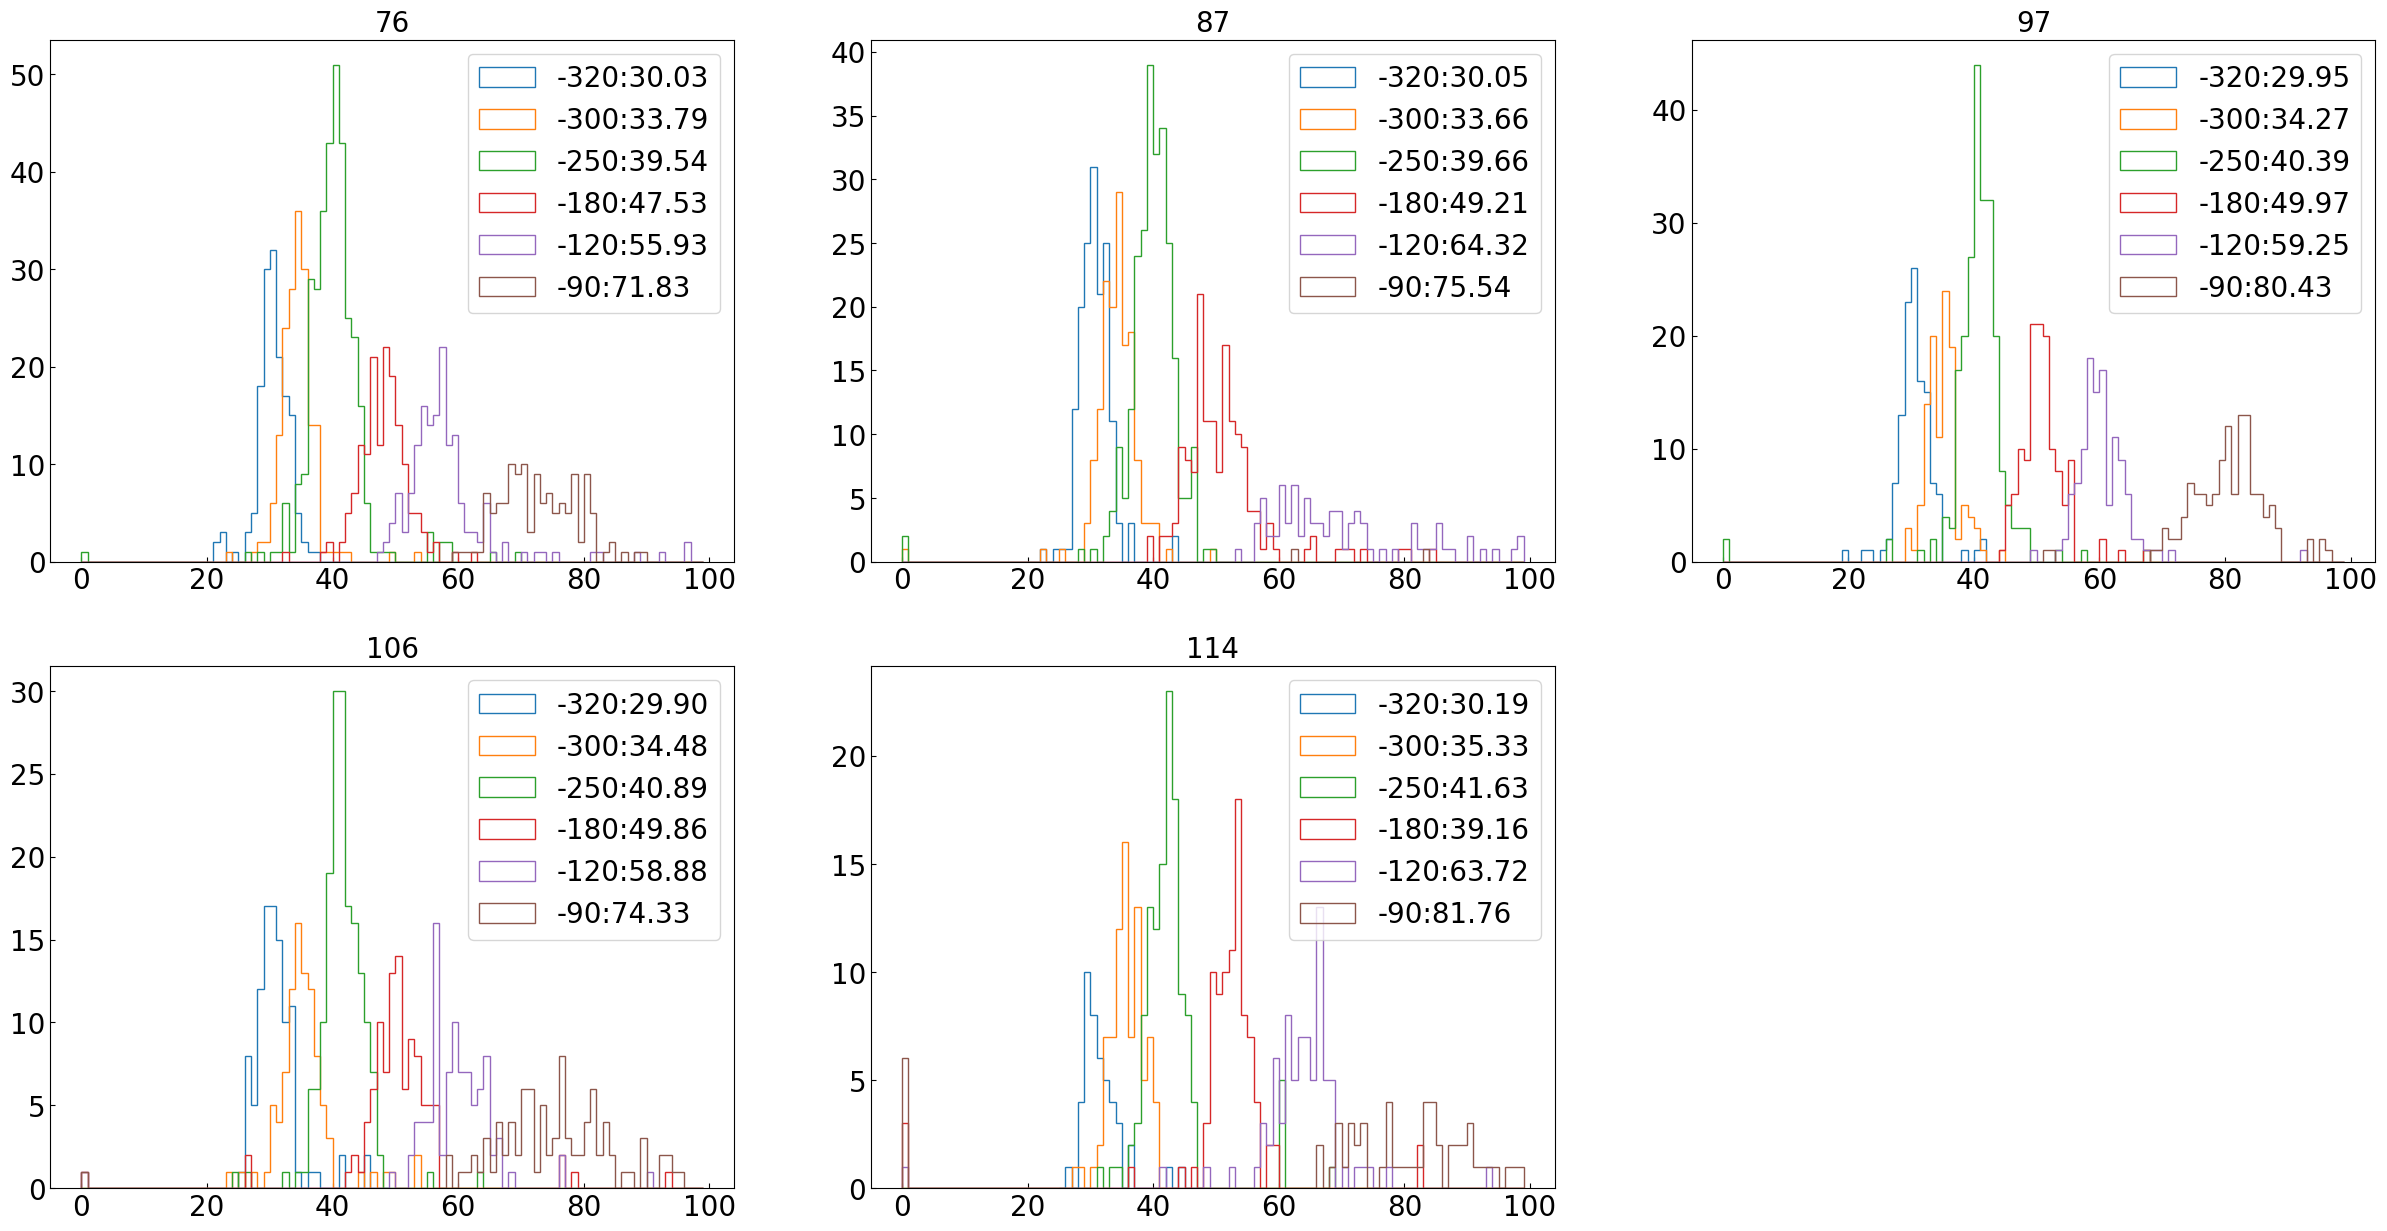

In [81]:
nrows,ncols=10,3
py.figure(figsize=(10*ncols,8*nrows))

ax=py.subplot(nrows,ncols,1)
ax.set_title('%d'%pixel[0],size=20)
ax.tick_params(direction='in',which='both',axis='both',labelsize=20)
y,x = np.histogram(risetime1389[0],bins = np.arange(0,100))
x = np.arange(0,99)
params, err = curve_fit(gaussian,x,y,p0 = [18,30,3])
ax.hist(risetime1389[0],bins=np.arange(0,100),histtype='step', label = '%d:%.2f'%(bias[0],params[1]))

y,x = np.histogram(risetime1391[0],bins = np.arange(0,100))
x = np.arange(0,99)
params, err = curve_fit(gaussian,x,y,p0 = [18,35,3])
ax.hist(risetime1391[0],bins=np.arange(0,100),histtype='step', label = '%d:%.2f'%(bias[1],params[1]))

y,x = np.histogram(risetime1392[0],bins = np.arange(0,100))
x = np.arange(0,99)
params, err = curve_fit(gaussian,x,y,p0 = [20,40,3])
ax.hist(risetime1392[0],bins=np.arange(0,100),histtype='step', label = '%d:%.2f'%(bias[2],params[1]))

y,x = np.histogram(risetime1393[0],bins = np.arange(0,100))
x = np.arange(0,99)
params, err = curve_fit(gaussian,x,y,p0 = [20,50,3])
ax.hist(risetime1393[0],bins=np.arange(0,100),histtype='step', label = '%d:%.2f'%(bias[3],params[1]))

y,x = np.histogram(risetime1395[0],bins = np.arange(0,100))
x = np.arange(0,99)
params, err = curve_fit(gaussian,x,y,p0 = [20,60,3])
ax.hist(risetime1395[0],bins=np.arange(0,100),histtype='step', label = '%d:%.2f'%(bias[4],params[1]))

y,x = np.histogram(risetime1399[0],bins = np.arange(0,100))
x = np.arange(0,99)
params, err = curve_fit(gaussian,x,y,p0 = [20,80,3])
ax.hist(risetime1399[0],bins=np.arange(0,100),histtype='step', label = '%d:%.2f'%(bias[5],params[1]))
ax.legend(loc="upper right",prop={'size':20})


ax=py.subplot(nrows,ncols,2)
ax.set_title('%d'%pixel[1],size=20)
ax.tick_params(direction='in',which='both',axis='both',labelsize=20)

y,x = np.histogram(risetime1389[1],bins = np.arange(0,100))
x = np.arange(0,99)
params, err = curve_fit(gaussian,x,y,p0 = [18,30,3])
ax.hist(risetime1389[1],bins=np.arange(0,100),histtype='step', label = '%d:%.2f'%(bias[0],params[1]))

y,x = np.histogram(risetime1391[1],bins = np.arange(0,100))
x = np.arange(0,99)
params, err = curve_fit(gaussian,x,y,p0 = [12,35,3])
ax.hist(risetime1391[1],bins=np.arange(0,100),histtype='step', label = '%d:%.2f'%(bias[1],params[1]))

y,x = np.histogram(risetime1392[1],bins = np.arange(0,100))
x = np.arange(0,99)
params, err = curve_fit(gaussian,x,y,p0 = [20,40,3])
ax.hist(risetime1392[1],bins=np.arange(0,100),histtype='step', label = '%d:%.2f'%(bias[2],params[1]))

y,x = np.histogram(risetime1393[1],bins = np.arange(0,100))
x = np.arange(0,99)
params, err = curve_fit(gaussian,x,y,p0 = [20,50,3])
ax.hist(risetime1393[1],bins=np.arange(0,100),histtype='step', label = '%d:%.2f'%(bias[3],params[1]))

y,x = np.histogram(risetime1395[1],bins = np.arange(0,100))
x = np.arange(0,99)
params, err = curve_fit(gaussian,x,y,p0 = [20,60,3])
ax.hist(risetime1395[1],bins=np.arange(0,100),histtype='step', label = '%d:%.2f'%(bias[4],params[1]))

y,x = np.histogram(risetime1399[1],bins = np.arange(0,100))
x = np.arange(0,99)
params, err = curve_fit(gaussian,x,y,p0 = [20,80,3])
ax.hist(risetime1399[1],bins=np.arange(0,100),histtype='step', label = '%d:%.2f'%(bias[5],params[1]))
ax.legend(loc="upper right",prop={'size':20})

ax=py.subplot(nrows,ncols,3)
ax.set_title('%d'%pixel[2],size=20)
ax.tick_params(direction='in',which='both',axis='both',labelsize=20)

y,x = np.histogram(risetime1389[2],bins = np.arange(0,100))
x = np.arange(0,99)
params, err = curve_fit(gaussian,x,y,p0 = [18,30,3])
ax.hist(risetime1389[2],bins=np.arange(0,100),histtype='step', label = '%d:%.2f'%(bias[0],params[1]))

y,x = np.histogram(risetime1391[2],bins = np.arange(0,100))
x = np.arange(0,99)
params, err = curve_fit(gaussian,x,y,p0 = [8,37,3])
ax.hist(risetime1391[2],bins=np.arange(0,100),histtype='step', label = '%d:%.2f'%(bias[1],params[1]))

y,x = np.histogram(risetime1392[2],bins = np.arange(0,100))
x = np.arange(0,99)
params, err = curve_fit(gaussian,x,y,p0 = [15,40,3])
ax.hist(risetime1392[2],bins=np.arange(0,100),histtype='step', label = '%d:%.2f'%(bias[2],params[1]))

y,x = np.histogram(risetime1393[2],bins = np.arange(0,100))
x = np.arange(0,99)
params, err = curve_fit(gaussian,x,y,p0 = [10,50,3])
ax.hist(risetime1393[2],bins=np.arange(0,100),histtype='step', label = '%d:%.2f'%(bias[3],params[1]))

y,x = np.histogram(risetime1395[2],bins = np.arange(0,100))
x = np.arange(0,99)
params, err = curve_fit(gaussian,x,y,p0 = [10,60,3])
ax.hist(risetime1395[2],bins=np.arange(0,100),histtype='step', label = '%d:%.2f'%(bias[4],params[1]))

y,x = np.histogram(risetime1399[2],bins = np.arange(0,100))
x = np.arange(0,99)
params, err = curve_fit(gaussian,x,y,p0 = [10,80,3])
ax.hist(risetime1399[2],bins=np.arange(0,100),histtype='step', label = '%d:%.2f'%(bias[5],params[1]))
ax.legend(loc="upper right",prop={'size':20})


ax=py.subplot(nrows,ncols,4)
ax.set_title('%d'%pixel[3],size=20)
ax.tick_params(direction='in',which='both',axis='both',labelsize=20)

y,x = np.histogram(risetime1389[3],bins = np.arange(0,100))
x = np.arange(0,99)
params, err = curve_fit(gaussian,x,y,p0 = [18,30,3])
ax.hist(risetime1389[3],bins=np.arange(25,50),histtype='step', label = '%d:%.2f'%(bias[0],params[1]))

y,x = np.histogram(risetime1391[3],bins = np.arange(0,100))
x = np.arange(0,99)
params, err = curve_fit(gaussian,x,y,p0 = [8,37,3])
ax.hist(risetime1391[3],bins=np.arange(0,100),histtype='step', label = '%d:%.2f'%(bias[1],params[1]))

y,x = np.histogram(risetime1392[3],bins = np.arange(0,100))
x = np.arange(0,99)
params, err = curve_fit(gaussian,x,y,p0 = [12,40,3])
ax.hist(risetime1392[3],bins=np.arange(0,100),histtype='step', label = '%d:%.2f'%(bias[2],params[1]))

y,x = np.histogram(risetime1393[3],bins = np.arange(0,100))
x = np.arange(0,99)
params, err = curve_fit(gaussian,x,y,p0 = [10,50,3])
ax.hist(risetime1393[3],bins=np.arange(0,100),histtype='step', label = '%d:%.2f'%(bias[3],params[1]))

y,x = np.histogram(risetime1395[3],bins = np.arange(0,100))
x = np.arange(0,99)
params, err = curve_fit(gaussian,x,y,p0 = [10,60,3])
ax.hist(risetime1395[3],bins=np.arange(0,100),histtype='step', label = '%d:%.2f'%(bias[4],params[1]))

y,x = np.histogram(risetime1399[3],bins = np.arange(0,100))
x = np.arange(0,99)
params, err = curve_fit(gaussian,x,y,p0 = [10,80,3])
ax.hist(risetime1399[3],bins=np.arange(0,100),histtype='step', label = '%d:%.2f'%(bias[5],params[1]))
ax.legend(loc="upper right",prop={'size':20})

ax=py.subplot(nrows,ncols,5)
ax.set_title('%d'%pixel[4],size=20)
ax.tick_params(direction='in',which='both',axis='both',labelsize=20)

y,x = np.histogram(risetime1389[4],bins = np.arange(0,100))
x = np.arange(0,99)
params, err = curve_fit(gaussian,x,y,p0 = [18,30,3])
ax.hist(risetime1389[4],bins=np.arange(25,50),histtype='step', label = '%d:%.2f'%(bias[0],params[1]))

y,x = np.histogram(risetime1391[4],bins = np.arange(0,100))
x = np.arange(0,99)
params, err = curve_fit(gaussian,x,y,p0 = [18,37,3])
ax.hist(risetime1391[4],bins=np.arange(0,100),histtype='step', label = '%d:%.2f'%(bias[1],params[1]))

y,x = np.histogram(risetime1392[4],bins = np.arange(0,100))
x = np.arange(0,99)
params, err = curve_fit(gaussian,x,y,p0 = [10,40,3])
ax.hist(risetime1392[4],bins=np.arange(0,100),histtype='step', label = '%d:%.2f'%(bias[2],params[1]))

y,x = np.histogram(risetime1393[4],bins = np.arange(0,100))
x = np.arange(0,99)
params, err = curve_fit(gaussian,x,y,p0 = [10,40,3])
ax.hist(risetime1393[4],bins=np.arange(0,100),histtype='step', label = '%d:%.2f'%(bias[3],params[1]))

y,x = np.histogram(risetime1395[4],bins = np.arange(0,100))
x = np.arange(0,99)
params, err = curve_fit(gaussian,x,y,p0 = [10,60,3])
ax.hist(risetime1395[4],bins=np.arange(0,100),histtype='step', label = '%d:%.2f'%(bias[4],params[1]))

y,x = np.histogram(risetime1399[4],bins = np.arange(0,100))
x = np.arange(0,99)
params, err = curve_fit(gaussian,x,y,p0 = [10,80,3])
ax.hist(risetime1399[4],bins=np.arange(0,100),histtype='step', label = '%d:%.2f'%(bias[5],params[1]))
ax.legend(loc="upper right",prop={'size':20})

plt.show()

In [74]:
d = pd.DataFrame(risetime1389).T
d = d.rename(columns={0: '76', 1: '87',2:'97',3:'106',4:'114'})
d

,76,87,97,106,114
0,31.368496,33.873071,31.704433,33.961165,31.822329
1,32.310305,36.251935,29.232000,30.492088,31.342628
2,30.015689,29.053414,30.669809,32.839711,32.121264
3,28.518794,33.684228,29.608737,31.406499,29.010438
4,30.563565,30.226684,29.067693,33.556290,30.405679
...,...,...,...,...,...
152,30.613422,29.906305,NaN,NaN,NaN
153,29.533962,36.038116,NaN,NaN,NaN
154,29.816146,29.370335,NaN,NaN,NaN
155,30.875769,30.944436,NaN,NaN,NaN


In [75]:
d.to_csv('risetime1389.csv',mode = 'w', header = True, index = False)

In [44]:
len(risetime1399[0])

175

In [ ]:
data = []
with open('/storage/home/hcoda1/4/ashelby8/calibration/risetime1399.csv') as f:
    csv.DictReader(f)
    data.append(pd.read_csv(f))
dataAll = pd.concat(data,ignore_index = True)

In [58]:
dataAll

,76,87,97,106,114
0,76.678874,177.145338,82.795676,71.016577,97.232348
1,77.332117,1441.429805,83.532871,126.577835,66.030730
2,65.305611,169.116556,81.464533,74.332641,72.161820
3,106.449017,142.843049,87.297416,71.007124,71.473871
4,558.474524,477.976959,73.582309,166.720321,77.766778
...,...,...,...,...,...
170,84.797931,NaN,NaN,NaN,NaN
171,78.586367,NaN,NaN,NaN,NaN
172,194.318442,NaN,NaN,NaN,NaN
173,69.550692,NaN,NaN,NaN,NaN
